# Experiment 1: Manual Categorization

This notebook implements **Experiment 1** of the thesis: predicting mental health risk 
levels among video gamers using **rule-based manual categorization** of open-ended 
survey responses.

**Prerequisite**: This notebook uses the cleaned dataset (`df_cleaned_data.csv`) produced 
by the preprocessing pipeline in `01_preprocessing_eda_embeddings.ipynb`. Both experiments 
share identical preprocessing; only the text feature transformation differs.

**Pipeline**: Feature Engineering → Feature Selection → Baseline Models → 
Hyperparameter Tuning → SHAP Analysis → Error Analysis → Test Set Evaluation


In [ ]:
import pandas as pd
# pip install xgboost
# pip install lightgbm
# pip install pytorch_tabnet
# pip install catboost
%pip install seaborn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, f1_score
import torch
import shap
import joblib
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.feature_selection import RFECV
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')


# Disable summarization
np.set_printoptions(threshold=np.inf)

# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows
pd.set_option('display.max_rows', None)

# Optional: show full width of columns (especially for long text)
pd.set_option('display.max_colwidth', None)



In [ ]:
csv_file_path = 'df_cleaned_data.csv'
df = pd.read_csv(csv_file_path, encoding="ISO-8859-1")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13444 entries, 0 to 13443
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GAD1                13444 non-null  float64
 1   GAD2                13444 non-null  float64
 2   GAD3                13444 non-null  float64
 3   GAD4                13444 non-null  float64
 4   GAD5                13444 non-null  float64
 5   GAD6                13444 non-null  float64
 6   GAD7                13444 non-null  float64
 7   SWL1                13444 non-null  float64
 8   SWL2                13444 non-null  float64
 9   SWL3                13444 non-null  float64
 10  SWL4                13444 non-null  float64
 11  SWL5                13444 non-null  float64
 12  Hours               13444 non-null  float64
 13  streams             13444 non-null  float64
 14  SPIN1               13444 non-null  float64
 15  SPIN2               13444 non-null  float64
 16  SPIN

# 1. Feature Engineering — Rule-Based Categorization

Open-ended responses (`whyplay`, `Playstyle`, `earnings`, `League`) are transformed 
into structured categorical variables using predefined domain-relevant keywords. 
For example, `whyplay` responses are mapped to categories like "having fun", 
"improving", "winning", "relaxing", "escaping". This approach offers high 
interpretability and aligns with established practices in behavioral research.


In [ ]:
# Clean the text for the features 'earnings', 'Playstyle', 'whyplay', 'League'

def clean_text(text):
  text = str(text).lower().strip()
  return ' '.join(word.strip(st.punctuation) for word in text.split())

df['whyplay_cleaned'] = df['whyplay'].apply(clean_text)
df['earnings_cleaned'] = df['earnings'].apply(clean_text)
df['Playstyle_cleaned'] = df['Playstyle'].apply(clean_text)
df['League_cleaned'] = df['League'].apply(clean_text)

In [ ]:
## categorization of 'whyplay' to handle multiple matches
def categorize_whyplay(text):
    text = str(text).lower()

    if text in ['improving']:
        return 'improving'
    if text in ['all of the above', 'all the above', 'all']:
        return 'all of the above'


    categories = {
        'having fun': ['fun', 'enjoy', 'enjoyment', 'pleasure'],
        'improving': ['improve', 'skill', 'practice', 'better', 'learn'],
        'winning': ['win', 'competitive', 'victory', 'ranked', 'rank'],
        'relaxing': ['relax', 'stress', 'chill', 'unwind', 'calm'],
        'escapism': ['escape', 'distraction', 'forget', 'avoid']
    }

    matches = []
    for category, keywords in categories.items():
        if any(keyword in text for keyword in keywords):
            matches.append(category)

    if len(matches) == 0:
        return 'other'
    elif len(matches) == 1:
        return matches[0]
    else:
        return 'all of the above'

df['whyplay_final'] = df['whyplay_cleaned'].apply(categorize_whyplay)

# Optional: check the distribution
print(df['whyplay_final'].value_counts())

whyplay_final
having fun          5366
improving           4931
winning             2128
relaxing             662
all of the above     191
other                154
escapism              12
Name: count, dtype: int64


In [ ]:
# categorization of 'Playstyle'
def categorize_playstyle_refined(text):
    text = str(text).lower()

    if any(conj in text for conj in [' and ','sometimes', 'depends', 'mix', 'combination', 'all', 'as much']):
        return 'all of the above'

    categories = {
        'multiplayer online with real life friends': [
            'real life friends', 'irl friends', 'offline friends online', 'real', 'rl'
        ],
        'multiplayer online with strangers': [
            'strangers', 'randoms', 'people i do not know'
        ],
        'multiplayer online with online acquaintances or teammates': [
            'online friends', 'acquaintances', 'teammates', 'guildmates', 'clanmates'
        ],
        'multiplayer offline people in the same room': [
            'same room', 'couch co-op', 'split screen', 'local multiplayer'
        ],
        'singleplayer': [
            'singleplayer', 'alone', 'solo game', 'campaign', 'solo'
        ]
    }

    matches = []
    for category, keywords in categories.items():
        if any(keyword in text for keyword in keywords):
            matches.append(category)

    if len(matches) == 0:
        return 'other'
    elif len(matches) == 1:
        return matches[0]
    else:
        return 'all of the above'

# Apply the refined categorization
df['Playstyle_final'] = df['Playstyle_cleaned'].apply(categorize_playstyle_refined)

# Show results
print(df['Playstyle_final'].value_counts())



Playstyle_final
multiplayer online with real life friends                    5572
multiplayer online with strangers                            4142
multiplayer online with online acquaintances or teammates    2650
singleplayer                                                  768
all of the above                                              227
multiplayer offline people in the same room                    49
other                                                          36
Name: count, dtype: int64


In [ ]:
#  categorization of 'earnings'
def categorize_earnings(text):
    text = str(text).lower()

    if 'earn a living' in text or 'full time' in text or 'my job' in text:
        return 'i earn a living by playing this game'
    elif 'earn a little' in text or 'on the side' in text or 'tournament winnings' in text or 'streaming' in text:
        return 'i play mostly for fun but earn a little on the side tournament winnings streaming etc'
    elif 'for fun' in text:
        return 'i play for fun'
    else:
        return 'other'

# Apply thecategorization
df['earnings_final'] = df['earnings_cleaned'].apply(categorize_earnings)


print(df['earnings_final'].value_counts())


earnings_final
i play for fun                                                                           12180
i play mostly for fun but earn a little on the side tournament winnings streaming etc      999
other                                                                                      213
i earn a living by playing this game                                                        52
Name: count, dtype: int64


In [ ]:
# categorization of "League"
df['League_cleaned'] = df['League'].astype(str).str.lower().str.strip()

def categorize_league(text):
    text = str(text).lower()

    categories = {
        'bronze': ['bronze', 'bronce', 'wood', 'elohell', 'broze'],
        'silver': ['silver', 'silverii', 'sliver', 'siver', 'silber', 'sil', 'silveriv'],
        'gold': ['gold', 'g', 'gv', 'golden', 'glod', 'golld', 'golf', 'goled', 'golderino', 'giii'],
        'platinum': [
            'platinum', 'platinium', 'platnium', 'platin', 'pplatinum', 'plarinum',
            'platium', 'platine', 'platinun', 'platonum', 'platnum', 'plata',
            'plantinum', 'platinuim', 'platunum', 'platinumm', 'platv', 'platina', 'plat'
        ],
        'diamond': ['diamond', 'dia', 'diaomnd', 'diamont', 'diamomd'],
        'master': ['master', 'masters'],
        'unranked': ['unranked']
    }

    for categories, keywords in categories.items():
        if any(k in text for k in keywords):
            return categories

    return 'Other'

# Apply the categorization
df['League_final'] = df['League_cleaned'].apply(categorize_league)

print(df['League_final'].value_counts())


League_final
gold        4885
silver      2763
platinum    2693
diamond     1610
bronze       551
unranked     427
Other        358
master       157
Name: count, dtype: int64


In [ ]:
df.head()

,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,SWL1,SWL2,SWL3,SWL4,SWL5,Hours,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Age,GAD_T,SWL_T,SPIN_T,GADE,Game,Platform,earnings,whyplay,League,Gender,Work,Degree,Reference,Playstyle,Residence_ISO3,Birthplace_ISO3,GamingTime,SWL_category,mental_health_risk,whyplay_cleaned,earnings_cleaned,Playstyle_cleaned,League_cleaned,whyplay_final,Playstyle_final,earnings_final,League_final
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,5.0,5.0,5.0,5.0,15.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,25.0,1.0,23.0,5.0,Not difficult at all,Skyrim,"Console (PS, Xbox, ...)",I play for fun,having fun,Gold,Male,Unemployed / between jobs,BachelorÂ (or equivalent),Reddit,Singleplayer,USA,USA,15.0,Slightly satisfied,Low risk,having fun,i play for fun,singleplayer,gold,having fun,singleplayer,i play for fun,gold
1,1.0,2.0,2.0,2.0,0.0,1.0,0.0,3.0,5.0,2.0,5.0,1.0,8.0,2.0,2.0,1.0,1.0,3.0,2.0,3.0,1.0,3.0,4.0,0.0,3.0,0.0,1.0,3.0,3.0,1.0,2.0,1.0,41.0,8.0,16.0,33.0,Somewhat difficult,Other,PC,I play for fun,having fun,Gold,Male,Unemployed / between jobs,BachelorÂ (or equivalent),Reddit,Multiplayer - online - with strangers,USA,USA,10.0,Slightly dissatisfied,Moderate risk,having fun,i play for fun,multiplayer online with strangers,gold,having fun,multiplayer online with strangers,i play for fun,gold
2,0.0,2.0,2.0,0.0,0.0,3.0,1.0,2.0,6.0,5.0,2.0,2.0,0.0,0.0,1.0,0.0,1.0,2.0,3.0,4.0,2.0,1.0,0.0,1.0,1.0,3.0,0.0,2.0,4.0,4.0,2.0,4.0,32.0,8.0,17.0,31.0,Not difficult at all,Other,PC,I play for fun,having fun,Gold,Female,Employed,BachelorÂ (or equivalent),Reddit,Singleplayer,DEU,DEU,0.0,Slightly dissatisfied,Moderate risk,having fun,i play for fun,singleplayer,gold,having fun,singleplayer,i play for fun,gold
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,5.0,5.0,3.0,2.0,20.0,5.0,2.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0,2.0,28.0,0.0,17.0,11.0,Not difficult at all,Other,PC,I play for fun,improving,Gold,Male,Employed,BachelorÂ (or equivalent),Reddit,Multiplayer - online - with online acquaintances or teammates,USA,USA,25.0,Slightly dissatisfied,Moderate risk,improving,i play for fun,multiplayer online with online acquaintances or teammates,gold,improving,multiplayer online with online acquaintances or teammates,i play for fun,gold
4,2.0,1.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,4.0,5.0,1.0,20.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,19.0,14.0,14.0,13.0,Very difficult,Other,"Console (PS, Xbox, ...)",I play for fun,having fun,Rank 15,Male,Employed,High school diploma (or equivalent),Reddit,Multiplayer - online - with strangers,KOR,USA,21.0,Dissatisfied,High risk,having fun,i play for fun,multiplayer online with strangers,rank 15,having fun,multiplayer online with strangers,i play for fun,Other


In [ ]:

#Apply Anova
f_stat_whyplay, p_value_whyplay = f_oneway(*[group['SWL_T'] for name, group in df.groupby('whyplay_final')])
f_stat_playstyle, p_value_playstyle = f_oneway(*[group['SWL_T'] for name, group in df.groupby('Playstyle_final')])
f_stat_earnings, p_value_earnings = f_oneway(*[group['SWL_T'] for name, group in df.groupby('earnings_final')])
f_stat_league, p_value_league = f_oneway(*[group['SWL_T'] for name, group in df.groupby('League_final')])

print(f"F-statistic (whyplay): {f_stat_whyplay}, P-value (whyplay): {p_value_whyplay}")
print(f"F-statistic (Playstyle): {f_stat_playstyle}, P-value (Playstyle): {p_value_playstyle}")
print(f"F-statistic (earnings): {f_stat_earnings}, P-value (earnings): {p_value_earnings}")
print(f"F-statistic (League): {f_stat_league}, P-value (League): {p_value_league}")

F-statistic (whyplay): 35.78305685991513, P-value (whyplay): 3.1803063687239477e-43
F-statistic (Playstyle): 43.278429066536724, P-value (Playstyle): 1.1673009487283736e-52
F-statistic (earnings): 32.97950169854516, P-value (earnings): 3.139403679256214e-21
F-statistic (League): 3.226803273632431, P-value (League): 0.0020223395629423136


In [ ]:
df = df.drop(columns=['whyplay', 'earnings', 'Playstyle', 'League', 'whyplay_cleaned', 'earnings_cleaned', 'Playstyle_cleaned', 'League_cleaned','SWL_category','SWL_T','SWL1','SWL2','SWL3','SWL4','SWL5','Birthplace_ISO3','Hours','streams'],axis=1)
df.shape


(13444, 42)

In [ ]:
top_countries = df['Residence_ISO3'].value_counts()[df['Residence_ISO3'].value_counts() >= 50].index
df['Residence_ISO3'] = df['Residence_ISO3'].apply(lambda x: x if x in top_countries else 'Other')

In [ ]:
df.to_csv('df_rule_cleaned.csv', index=False)

In [ ]:
csv_file_path = 'df_rule_cleaned.csv'
df = pd.read_csv(csv_file_path, encoding="ISO-8859-1")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13444 entries, 0 to 13443
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GAD1                13444 non-null  float64
 1   GAD2                13444 non-null  float64
 2   GAD3                13444 non-null  float64
 3   GAD4                13444 non-null  float64
 4   GAD5                13444 non-null  float64
 5   GAD6                13444 non-null  float64
 6   GAD7                13444 non-null  float64
 7   SPIN1               13444 non-null  float64
 8   SPIN2               13444 non-null  float64
 9   SPIN3               13444 non-null  float64
 10  SPIN4               13444 non-null  float64
 11  SPIN5               13444 non-null  float64
 12  SPIN6               13444 non-null  float64
 13  SPIN7               13444 non-null  float64
 14  SPIN8               13444 non-null  float64
 15  SPIN9               13444 non-null  float64
 16  SPIN

In [ ]:
df = df.drop(columns=['Reference'],axis=1)
df.shape

(13444, 41)

# 2. Data Splitting & Scaling

- **70/15/15** stratified split: training / validation / test
- **Encoded + Scaled** version: one-hot encoding + StandardScaler (for LR, RF, SVM, XGBoost, LightGBM)
- **Raw** version: unprocessed (for CatBoost native categorical handling)


In [ ]:
# Custom mapping based on target
risk_order = {
    'Low risk': 0,
    'Moderate risk': 1,
    'High risk': 2
}

df['mental_health_risk_encoded'] = df['mental_health_risk'].map(risk_order)
df.mental_health_risk_encoded.value_counts()

,count
mental_health_risk_encoded,
0,6368
1,3541
2,3535


In [ ]:
X = df.drop(columns=['mental_health_risk', 'mental_health_risk_encoded'])
y = df['mental_health_risk_encoded']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=["float64", "float32", "int64"]).columns.tolist()


# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)


# Scale numerical features
scaler = StandardScaler()
X_encoded[numerical_features] = scaler.fit_transform(X_encoded[numerical_features])

# Stratified split: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

# Output shapes and sanity check
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)




Train shape: (9410, 106)
Validation shape: (2017, 106)
Test shape: (2017, 106)


In [ ]:
#RAW VERSION FOR TABNET, CATBOOST
# Separate features and target
df_raw_rule = df.copy()
X_raw = df_raw_rule.drop(columns=['mental_health_risk', 'mental_health_risk_encoded'])
y_raw = df_raw_rule['mental_health_risk_encoded']

# Stratified split for raw version (same proportions as before)
X_temp_raw, X_test_raw, y_temp_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.15, random_state=42, stratify=y_raw)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X_temp_raw, y_temp_raw, test_size=0.1765, random_state=42, stratify=y_temp_raw)

# Output confirmation
X_train_raw.shape, X_val_raw.shape, X_test_raw.shape



((9410, 40), (2017, 40), (2017, 40))

In [ ]:
X_train_raw.head()

,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Age,GAD_T,SPIN_T,GADE,Game,Platform,Gender,Work,Degree,Reference,Residence_ISO3,GamingTime,whyplay_final,Playstyle_final,earnings_final,League_final
13217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,2.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,25.0,0.0,11.0,Not difficult at all,League of Legends,PC,Male,Employed,High school diploma (or equivalent),Reddit,GBR,45.0,relaxing,multiplayer online with strangers,i play for fun,gold
4664,3.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,0.0,1.0,1.0,1.0,2.0,3.0,0.0,0.0,4.0,2.0,1.0,1.0,2.0,0.0,2.0,2.0,20.0,13.0,23.0,Very difficult,League of Legends,PC,Male,Student at college / university,MasterÃÂ (or equivalent),Reddit,GRC,70.0,winning,multiplayer online with strangers,i play for fun,gold
10417,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,29.0,6.0,4.0,Somewhat difficult,Other,PC,Male,Employed,MasterÃÂ (or equivalent),Reddit,FRA,16.0,having fun,multiplayer online with strangers,i play for fun,gold
11476,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,19.0,0.0,7.0,Not difficult at all,League of Legends,PC,Male,Unemployed / between jobs,High school diploma (or equivalent),Reddit,NOR,55.0,improving,multiplayer online with real life friends,i play for fun,gold
3780,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,3.0,2.0,2.0,3.0,3.0,3.0,2.0,3.0,1.0,4.0,3.0,2.0,3.0,2.0,2.0,2.0,1.0,18.0,3.0,41.0,Not difficult at all,League of Legends,PC,Male,Student at school,High school diploma (or equivalent),Reddit,POL,24.0,having fun,all of the above,i play for fun,silver


# 3. Feature Selection

Four methods applied: Random Forest importance, ANOVA F-test, Mutual Information, 
and RFECV (with LR and XGBoost). Features in ≥3 methods form the Consensus set. 
Five feature sets generated for comparison.


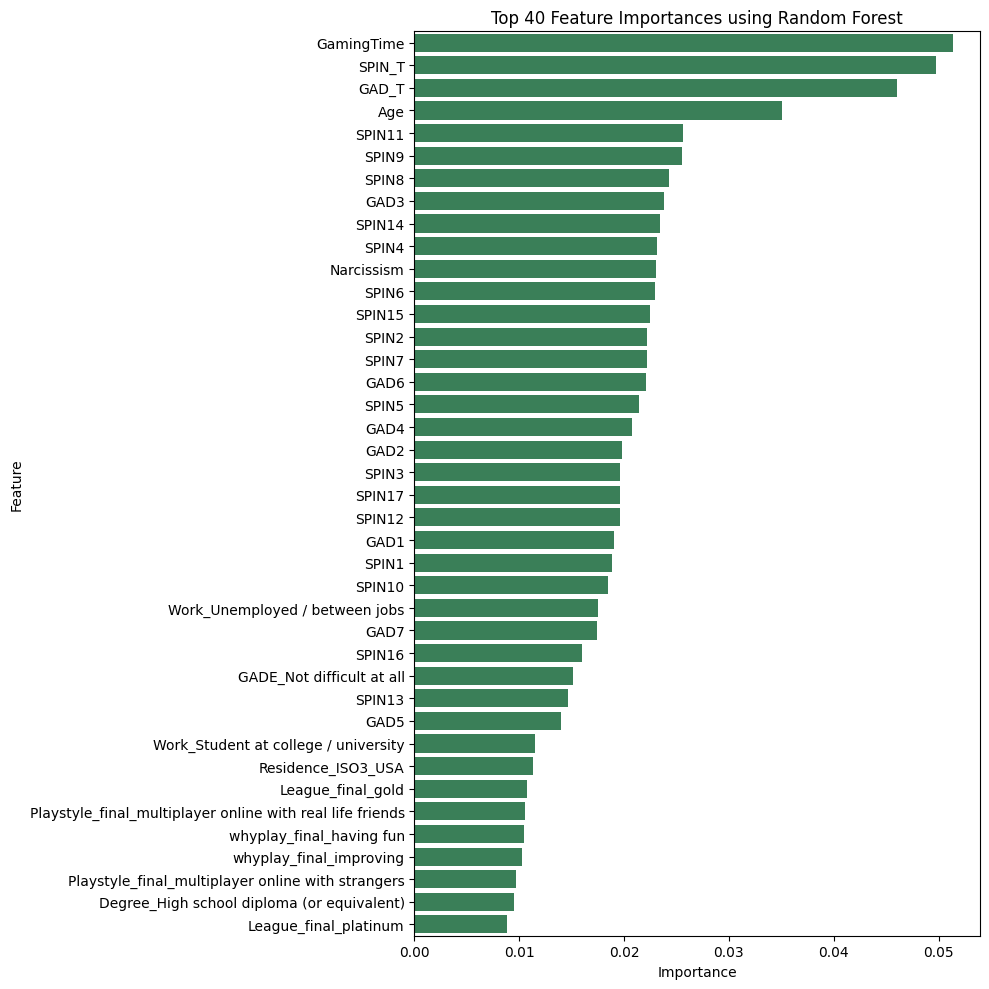

,GamingTime,SPIN_T,GAD_T,Age,SPIN11,SPIN9,SPIN8,GAD3,SPIN14,SPIN4,Narcissism,SPIN6,SPIN15,SPIN2,SPIN7,GAD6,SPIN5,GAD4,GAD2,SPIN3
13217,0.736816,-0.658995,-1.106255,1.237707,1.469469,0.316322,-1.025822,-0.983071,-1.040998,-0.559991,-0.968710,-0.270635,-1.048288,-1.062999,-0.039319,-0.978333,-1.022908,-0.785498,-0.735309,-0.944132
4664,2.150679,0.238029,1.654123,-0.281654,1.469469,-1.138123,1.171541,1.052572,-0.207922,-0.559991,-0.025205,-0.270635,0.440522,0.695494,0.783790,1.170978,-0.201052,0.299718,1.449813,-0.944132
10417,-0.903266,-1.182259,0.167766,2.453195,-1.235455,-0.410900,-0.293368,0.034750,-1.040998,-1.378183,-0.968710,-1.056593,-1.048288,-1.062999,-0.862428,0.096323,-0.201052,0.299718,0.357252,-0.081126
11476,1.302361,-0.958003,-1.106255,-0.585526,-0.559224,0.316322,-1.025822,-0.983071,-1.040998,0.258201,-0.968710,-1.056593,-1.048288,-1.062999,-0.862428,-0.978333,-1.022908,-0.785498,-0.735309,-0.944132
3780,-0.450830,1.583566,-0.469245,-0.889398,1.469469,1.043544,0.439087,-0.983071,1.458228,0.258201,-0.968710,1.301279,0.440522,1.574741,1.606899,0.096323,1.442659,-0.785498,-0.735309,0.781880


In [ ]:
#FEATURE IMPORTANCE USING RANDOM FOREST

forest = RandomForestClassifier(random_state=42)
forest.fit(X_train, y_train)
importances = forest.feature_importances_
forest_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot top 40 features
plt.figure(figsize=(10, 10))
sns.barplot(x='Importance', y='Feature', data=forest_importances.head(40), color='seagreen')
plt.title("Top 40 Feature Importances using Random Forest")
plt.tight_layout()
plt.savefig("Top_40RULE_Feature_Importances_using_Random_Forest.pdf", format='pdf')
plt.show()


top_features_datasets = {}
for n_features in [5, 10, 15, 20, 25, 30,40]:
    top_n_features = forest_importances['Feature'].head(n_features)
    X_top_n = X_train[top_n_features]
    top_features_datasets[f'top_{n_features}_features'] = X_top_n

top_features_datasets['top_20_features'].head()


In [ ]:
# ANOVA F-test

# Feature selection using ANOVA (F-test)
selector = SelectKBest(score_func=f_classif, k=30)
selector.fit(X_train, y_train)
anova_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'ANOVA_F_score': selector.scores_,
    'ANOVA_p_value': selector.pvalues_
    }).sort_values(by='ANOVA_F_score', ascending=False)

print("ANOVA F-test scores:")
print(anova_scores.head(40))




ANOVA F-test scores:
                                                                      Feature  \
26                                                                      GAD_T   
1                                                                        GAD2   
2                                                                        GAD3   
3                                                                        GAD4   
0                                                                        GAD1   
29                                                  GADE_Not difficult at all   
27                                                                     SPIN_T   
6                                                                        GAD7   
5                                                                        GAD6   
20                                                                     SPIN14   
12                                                                      SPIN6   
48     

In [ ]:
# Mutual Information
mi_scores= mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Mutual_Information': mi_scores
}).sort_values(by='Mutual_Information', ascending=False)

print("Mutual Information Scores:")
print(mi_df)

Mutual Information Scores:
                                                                                                  Feature  \
26                                                                                                  GAD_T   
1                                                                                                    GAD2   
29                                                                              GADE_Not difficult at all   
2                                                                                                    GAD3   
3                                                                                                    GAD4   
0                                                                                                    GAD1   
27                                                                                                 SPIN_T   
20                                                                                                 SP

In [ ]:

# Initialize Logistic Regression model
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# Apply RFECV
rfecv = RFECV(
    estimator=log_reg,
    step=1,
    cv=StratifiedKFold(5),
    scoring='f1_macro',
    n_jobs=-1
)
rfecv.fit(X_train, y_train)
selected_features = X_train.columns[rfecv.support_]

selected_rfecv_df = pd.DataFrame({'Selected_Features': selected_features})

In [ ]:
print("Selected Features using RFECV_logreg:")
print(selected_rfecv_df)

Selected Features using RFECV_logreg:
                                                                                        Selected_Features
0                                                                                                    GAD1
1                                                                                                    GAD2
2                                                                                                    GAD3
3                                                                                                    GAD4
4                                                                                                    GAD5
5                                                                                                    GAD6
6                                                                                                    GAD7
7                                                                                                   SPIN1
8       

In [ ]:
#Apply RFECV with XGBoost

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, max_depth=5)

rfecv_xgb = RFECV(
    estimator=xgb_model,
    step=2,
    cv=StratifiedKFold(5),
    scoring='f1_macro',
    n_jobs=-1
)

rfecv_xgb.fit(X_train, y_train)
selected_features_xgb = X_train.columns[rfecv_xgb.support_]


In [ ]:
print("Selected Features using RFECV with XGBoost:")
print(selected_features_xgb)

Selected Features using RFECV with XGBoost:
Index(['GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'SPIN1',
       'SPIN2', 'SPIN3', 'SPIN4', 'SPIN5', 'SPIN6', 'SPIN7', 'SPIN8', 'SPIN9',
       'SPIN10', 'SPIN11', 'SPIN12', 'SPIN13', 'SPIN14', 'SPIN15', 'SPIN16',
       'SPIN17', 'Narcissism', 'Age', 'GAD_T', 'SPIN_T', 'GamingTime',
       'GADE_Not difficult at all', 'GADE_Somewhat difficult',
       'GADE_Very difficult', 'Game_Diablo 3', 'Game_League of Legends',
       'Game_Other', 'Game_Starcraft 2', 'Game_World of Warcraft',
       'Platform_PC', 'Gender_Male', 'Work_Student at college / university',
       'Work_Student at school', 'Work_Unemployed / between jobs',
       'Degree_High school diploma (or equivalent)',
       'Degree_MasterÃÂ (or equivalent)', 'Residence_ISO3_AUS',
       'Residence_ISO3_BEL', 'Residence_ISO3_BGR', 'Residence_ISO3_BRA',
       'Residence_ISO3_CAN', 'Residence_ISO3_CHE', 'Residence_ISO3_DEU',
       'Residence_ISO3_DNK', 'Residence_ISO3_E

In [ ]:
# 3. RFECV - XGBoost (AUC) features
rfecv_xgb_features = selected_features_xgb.tolist()
X_train_rfecv_xgb = X_train[rfecv_xgb_features]
X_val_rfecv_xgb = X_val[rfecv_xgb_features]
X_test_rfecv_xgb = X_test[rfecv_xgb_features]


In [ ]:

# Convert feature lists to sets (use actual lists if available)
top50_rf = set(forest_importances['Feature'].head(50).tolist())
top20_rf = set(forest_importances['Feature'].head(20).tolist())
top50_anova = set(anova_scores['Feature'].head(50).tolist())
top50_mi = set(mi_df['Feature'].head(50).tolist())
top50_rfecv_logr = set(selected_rfecv_df['Selected_Features'].tolist())
top50_rfecv_xgb = set(selected_features_xgb.tolist())


In [ ]:
# Create reduced datasets for modeling using different feature sets


# 1. Full feature set (no changes)
full_features_train = X_train.copy()
full_features_val = X_val.copy()
full_features_test = X_test.copy()

# 2. RFECV - Logistic Regression features
rfecv_logreg_features = selected_rfecv_df['Selected_Features'].tolist()
X_train_rfecv_logreg = X_train[rfecv_logreg_features]
X_val_rfecv_logreg = X_val[rfecv_logreg_features]
X_test_rfecv_logreg = X_test[rfecv_logreg_features]

# 3. RFECV - XGBoost (AUC) features
rfecv_xgb_features = selected_features_xgb.tolist()
X_train_rfecv_xgb = X_train[rfecv_xgb_features]
X_val_rfecv_xgb = X_val[rfecv_xgb_features]
X_test_rfecv_xgb = X_test[rfecv_xgb_features]

# 4. Consensus set: features that appear in 5 methods
# Build all feature sets first
top50_rf = set(forest_importances['Feature'].head(50).tolist())
top50_anova = set(anova_scores['Feature'].head(50).tolist())
top50_mi = set(mi_df['Feature'].head(50).tolist())
top50_rfecv_logreg = set(selected_rfecv_df['Selected_Features'].tolist())
top50_rfecv_auc = set(selected_features_xgb.tolist())

# Count occurrences
from collections import Counter
feature_counts = Counter(
    feat for group in [top50_rf, top50_anova, top50_mi, top50_rfecv_logreg, top50_rfecv_auc]
    for feat in group
)
consensus_features = [feat for feat, count in feature_counts.items() if count >= 3]

X_train_consensus = X_train[consensus_features]
X_val_consensus = X_val[consensus_features]
X_test_consensus = X_test[consensus_features]

# 5 Top 20 from Random Forest importnace
rf_top20 = forest_importances['Feature'].head(20).tolist()

X_train_rf20 = X_train[rf_top20]
X_val_rf20 = X_val[rf_top20]
X_test_rf20 = X_test[rf_top20]

# Summary of dataset shapes
summary = {
    "Full": full_features_train.shape[1],
    "RFECV_LogReg": X_train_rfecv_logreg.shape[1],
    "RFECV_XGB": X_train_rfecv_xgb.shape[1],
    "Consensus (5 methods)": X_train_consensus.shape[1],
    "Top-20 RF": X_train_rf20.shape[1]
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Number of Features'])
print(summary_df)
full_features_train.to_csv('full_features_train_rule.csv', index=False)
X_train_rfecv_logreg.to_csv('X_train_rfecv_logreg_rule.csv', index=False)
X_train_rfecv_xgb.to_csv('X_train_rfecv_xgb_rule.csv', index=False)
X_train_consensus.to_csv('X_train_consensus_rule.csv', index=False)
X_train_rf20.to_csv('X_train_union20_rule.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_val_rfecv_logreg.to_csv('X_val_rfecv_logreg_rule.csv', index=False)
X_val_rfecv_xgb.to_csv('X_val_rfecv_xgb_rule.csv', index=False)
X_val_consensus.to_csv('X_val_consensus_rule.csv', index=False)
X_val_rf20.to_csv('X_val_union20_rule.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
X_test_rfecv_logreg.to_csv('X_test_rfecv_logreg_rule.csv', index=False)
X_test_rfecv_xgb.to_csv('X_test_rfecv_xgb_rule.csv', index=False)
X_test_consensus.to_csv('X_test_consensus_rule.csv', index=False)
X_test_rf20.to_csv('X_test_union20_rule.csv', index=False)
y_test.to_csv('y_test.csv', index=False)



                       Number of Features
Full                                  106
RFECV_LogReg                          105
RFECV_XGB                              88
Consensus (5 methods)                  64
Top-20 RF                              20


# 4. Baseline Models

Seven models with default hyperparameters, evaluated via 5-fold stratified CV. 
Primary metric: **F1 Macro**. Models: LR, RF, SVM, XGBoost, LightGBM, CatBoost, TabNet.


In [ ]:
df_full = full_features_train.copy()
df_logreg = X_train_rfecv_logreg.copy()
df_xgb = X_train_rfecv_xgb.copy()
df_consensus = X_train_consensus.copy()
df_rf20 = X_train_rf20.copy()


In [ ]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize Logistic Regression model
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

# Evaluate across feature sets
logreg_results = []

feature_sets = {
    "Full_RULE": df_full,
    "RFECV_LogReg_RULE": df_logreg,
    "RFECV_XGB_RULE": df_xgb,
    "Consensus_5_Methods_RULE": df_consensus,
    "Top20_rf_RULE": df_rf20
}

for name, X in feature_sets.items():
     accuracy = cross_val_score(log_reg, X, y_train, cv=skf, scoring='accuracy')
     precision = cross_val_score(log_reg, X, y_train, cv=skf, scoring='precision_macro')
     recall = cross_val_score(log_reg, X, y_train, cv=skf, scoring='recall_macro')
     f1 = cross_val_score(log_reg, X, y_train, cv=skf, scoring='f1_macro')
     auc = cross_val_score(log_reg, X, y_train, cv=skf, scoring='roc_auc_ovr')


     logreg_results.append({
        "Feature Set": name,
        "Accuracy": f"{accuracy.mean():.4f} ± {accuracy.std():.4f}",
        "Precision": f"{precision.mean():.4f} ± {precision.std():.4f}",
        "Recall": f"{recall.mean():.4f} ± {recall.std():.4f}",
        "F1 Score": f"{f1.mean():.4f} ± {f1.std():.4f}",
        "AUC": f"{auc.mean():.4f} ± {auc.std():.4f}"
    })

# Display results
logreg_results_df = pd.DataFrame(logreg_results)
print(logreg_results_df)


                Feature Set         Accuracy        Precision  \
0                 Full_RULE  0.5642 ± 0.0038  0.4936 ± 0.0057   
1         RFECV_LogReg_RULE  0.5646 ± 0.0047  0.4958 ± 0.0068   
2            RFECV_XGB_RULE  0.5659 ± 0.0031  0.4980 ± 0.0048   
3  Consensus_5_Methods_RULE  0.5666 ± 0.0050  0.4997 ± 0.0099   
4             Top20_rf_RULE  0.5471 ± 0.0060  0.4718 ± 0.0163   

            Recall         F1 Score              AUC  
0  0.4873 ± 0.0061  0.4582 ± 0.0058  0.6996 ± 0.0105  
1  0.4880 ± 0.0067  0.4593 ± 0.0062  0.6998 ± 0.0106  
2  0.4894 ± 0.0051  0.4605 ± 0.0052  0.7002 ± 0.0106  
3  0.4886 ± 0.0053  0.4576 ± 0.0066  0.7016 ± 0.0112  
4  0.4599 ± 0.0083  0.4088 ± 0.0096  0.6755 ± 0.0102  


In [ ]:
# Initialize Random Forest

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_forest = RandomForestClassifier(random_state=42)

random_forest_results = []

feature_sets = {
    "Full": df_full,
    "RFECV_LogReg_rule": df_logreg,
    "RFECV_XGB_rule": df_xgb,
    "Consensus_5_Methods_rule": df_consensus,
    "Top20_RF_rule": df_rf20
}

for name, X in feature_sets.items():
     accuracy = cross_val_score(random_forest, X, y_train, cv=skf, scoring='accuracy')
     precision = cross_val_score(random_forest, X, y_train, cv=skf, scoring='precision_macro')
     recall = cross_val_score(random_forest, X, y_train, cv=skf, scoring='recall_macro')
     f1 = cross_val_score(random_forest, X, y_train, cv=skf, scoring='f1_macro')
     auc = cross_val_score(random_forest, X, y_train, cv=skf, scoring='roc_auc_ovr')


     random_forest_results.append({
        "Feature Set": name,
        "Accuracy": f"{accuracy.mean():.4f} ± {accuracy.std():.4f}",
        "Precision": f"{precision.mean():.4f} ± {precision.std():.4f}",
        "Recall": f"{recall.mean():.4f} ± {recall.std():.4f}",
        "F1 Score": f"{f1.mean():.4f} ± {f1.std():.4f}",
        "AUC": f"{auc.mean():.4f} ± {auc.std():.4f}"
    })

# Display results
random_forest_df = pd.DataFrame(random_forest_results)
print(random_forest_df)



           Feature Set         Accuracy        Precision           Recall  \
0                 Full  0.5533 ± 0.0076  0.4830 ± 0.0146  0.4759 ± 0.0093   
1         RFECV_LogReg  0.5578 ± 0.0053  0.4947 ± 0.0080  0.4794 ± 0.0072   
2        RFECV_XGB_AUC  0.5570 ± 0.0074  0.4950 ± 0.0153  0.4789 ± 0.0090   
3  Consensus_5_Methods  0.5553 ± 0.0057  0.4921 ± 0.0092  0.4793 ± 0.0069   
4             Top20_RF  0.5352 ± 0.0054  0.4677 ± 0.0075  0.4608 ± 0.0064   

          F1 Score              AUC  
0  0.4472 ± 0.0083  0.6838 ± 0.0086  
1  0.4537 ± 0.0064  0.6885 ± 0.0100  
2  0.4531 ± 0.0101  0.6853 ± 0.0086  
3  0.4567 ± 0.0072  0.6875 ± 0.0072  
4  0.4402 ± 0.0052  0.6578 ± 0.0057  


In [ ]:
#Initialise SVM Model

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm = SVC(probability=True, random_state=42)

svm_results = []

feature_sets = {
    "Full_rule": df_full,
    "RFECV_LogReg_rule": df_logreg,
    "RFECV_XGB_rule": df_xgb,
    "Consensus_5_Methods_rule": df_consensus,
    "Top20_rf_rule": df_rf20
}

for name, X in feature_sets.items():
     accuracy = cross_val_score(svm, X, y_train, cv=skf, scoring='accuracy')
     precision = cross_val_score(svm, X, y_train, cv=skf, scoring='precision_macro')
     recall = cross_val_score(svm, X, y_train, cv=skf, scoring='recall_macro')
     f1 = cross_val_score(svm, X, y_train, cv=skf, scoring='f1_macro')
     auc = cross_val_score(svm, X, y_train, cv=skf, scoring='roc_auc_ovr')

     svm_results.append({
        "Feature Set": name,
        "Accuracy": f"{accuracy.mean():.4f} ± {accuracy.std():.4f}",
        "Precision": f"{precision.mean():.4f} ± {precision.std():.4f}",
        "Recall": f"{recall.mean():.4f} ± {recall.std():.4f}",
        "F1 Score": f"{f1.mean():.4f} ± {f1.std():.4f}",
        "AUC": f"{auc.mean():.4f} ± {auc.std():.4f}"
            })

# Display results
svm_df = pd.DataFrame(svm_results)
print(svm_df)





                Feature Set         Accuracy        Precision  \
0                 Full_rule  0.5571 ± 0.0044  0.4882 ± 0.0094   
1         RFECV_LogReg_rule  0.5573 ± 0.0050  0.4884 ± 0.0110   
2            RFECV_XGB_rule  0.5574 ± 0.0041  0.4896 ± 0.0105   
3  Consensus_5_Methods_rule  0.5576 ± 0.0046  0.4905 ± 0.0100   
4             Top20_rf_rule  0.5443 ± 0.0048  0.4797 ± 0.0268   

            Recall         F1 Score              AUC  
0  0.4736 ± 0.0055  0.4398 ± 0.0054  0.6866 ± 0.0091  
1  0.4739 ± 0.0060  0.4401 ± 0.0056  0.6868 ± 0.0092  
2  0.4739 ± 0.0053  0.4405 ± 0.0054  0.6865 ± 0.0092  
3  0.4747 ± 0.0056  0.4420 ± 0.0056  0.6857 ± 0.0091  
4  0.4559 ± 0.0058  0.4129 ± 0.0072  0.6475 ± 0.0052  


## 4.1 Advanced Models (XGBoost, LightGBM, CatBoost, TabNet)


In [ ]:
# Initialize XGBoost Model
# Set up stratified k-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize XGBoost classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Define feature sets (same as used in the SVM approach)
feature_sets = {
    "Full_rule": df_full,
    "RFECV_LogReg_rule": df_logreg,
    "RFECV_XGB_rule": df_xgb,
    "Consensus_5_Methods_rule": df_consensus,
    "Top20_rf_rule": df_rf20
}

# Store results
xgb_results = []

# Perform cross-validation for each feature set
for name, X in feature_sets.items():
    accuracy = cross_val_score(xgb_model, X, y_train, cv=skf, scoring='accuracy')
    precision = cross_val_score(xgb_model, X, y_train, cv=skf, scoring='precision_macro')
    recall = cross_val_score(xgb_model, X, y_train, cv=skf, scoring='recall_macro')
    f1 = cross_val_score(xgb_model, X, y_train, cv=skf, scoring='f1_macro')
    auc = cross_val_score(xgb_model, X, y_train, cv=skf, scoring='roc_auc_ovr')

    xgb_results.append({
        "Feature Set": name,
        "Accuracy": f"{accuracy.mean():.4f} ± {accuracy.std():.4f}",
        "Precision": f"{precision.mean():.4f} ± {precision.std():.4f}",
        "Recall": f"{recall.mean():.4f} ± {recall.std():.4f}",
        "F1 Score": f"{f1.mean():.4f} ± {f1.std():.4f}",
        "AUC": f"{auc.mean():.4f} ± {auc.std():.4f}"
    })

# Display results
xgb_df = pd.DataFrame(xgb_results)
print("\nXGBoost - 5-Fold Cross-Validation Results for Multiple Feature Sets:")
print(xgb_df)




XGBoost - 5-Fold Cross-Validation Results for Multiple Feature Sets:
                Feature Set         Accuracy        Precision  \
0                 Full_rule  0.5392 ± 0.0035  0.4809 ± 0.0044   
1         RFECV_LogReg_rule  0.5451 ± 0.0049  0.4885 ± 0.0128   
2            RFECV_XGB_rule  0.5403 ± 0.0056  0.4822 ± 0.0078   
3  Consensus_5_Methods_rule  0.5399 ± 0.0061  0.4823 ± 0.0083   
4             Top20_rf_rule  0.5157 ± 0.0066  0.4578 ± 0.0077   

            Recall         F1 Score              AUC  
0  0.4771 ± 0.0042  0.4689 ± 0.0041  0.6750 ± 0.0075  
1  0.4838 ± 0.0081  0.4760 ± 0.0105  0.6750 ± 0.0069  
2  0.4795 ± 0.0070  0.4715 ± 0.0071  0.6738 ± 0.0066  
3  0.4790 ± 0.0085  0.4714 ± 0.0094  0.6738 ± 0.0072  
4  0.4525 ± 0.0060  0.4442 ± 0.0062  0.6406 ± 0.0016  


In [ ]:
# Initialize LightGBM Model

# Set up stratified k-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize LightGBM classifier with error handling
lgbm_model = LGBMClassifier(force_col_wise=True, random_state=42, verbose=-1)

# Define feature sets (same as used in the SVM approach)
feature_sets = {
    "Full_rule": df_full,
    "RFECV_LogReg_rule": df_logreg,
    "RFECV_XGB_rule": df_xgb,
    "Consensus_5_Methods_rule": df_consensus,
    "Top20_rf_rule": df_rf20
}

# Helper function to clean feature names that cause LightGBM errors
def clean_dataframe_for_lightgbm(df):
    # Create a copy to avoid modifying the original
    clean_df = df.copy()

    # Clean column names to avoid LightGBM's JSON character issue
    clean_df.columns = [col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
                       .replace('>', '_gt_').replace(':', '_colon_').replace('"', '_quote_')
                       .replace('{', '_brace1_').replace('}', '_brace2_').replace(',', '_comma_')
                       for col in clean_df.columns]

    return clean_df

# Store results
lgbm_results = []

# Perform cross-validation for each feature set - manually to avoid the feature name issue
for name, X_original in feature_sets.items():
    print(f"Processing {name} feature set...")

    # Clean feature names
    X = clean_dataframe_for_lightgbm(X_original)

    # Manual cross-validation to handle potential errors
    accuracies, precisions, recalls, f1s, aucs = [], [], [], [], []

    # Perform manual cross-validation
    for train_idx, val_idx in skf.split(X, y_train):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]

        try:
            # Fit model
            lgbm_model.fit(X_train_fold, y_train_fold)

            # Make predictions
            y_pred = lgbm_model.predict(X_val_fold)
            y_proba = lgbm_model.predict_proba(X_val_fold)

            # Binarize targets for ROC AUC
            classes = sorted(y_train.unique())
            y_val_bin = label_binarize(y_val_fold, classes=classes)

            # Calculate metrics
            accuracies.append(accuracy_score(y_val_fold, y_pred))
            precisions.append(precision_score(y_val_fold, y_pred, average='macro'))
            recalls.append(recall_score(y_val_fold, y_pred, average='macro'))
            f1s.append(f1_score(y_val_fold, y_pred, average='macro'))
            aucs.append(roc_auc_score(y_val_bin, y_proba, average='macro', multi_class='ovr'))
        except Exception as e:
            print(f"Error in fold: {str(e)}")
            continue

    # Only append results if we have valid metrics
    if accuracies:
        lgbm_results.append({
            "Feature Set": name,
            "Accuracy": f"{np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}",
            "Precision": f"{np.mean(precisions):.4f} ± {np.std(precisions):.4f}",
            "Recall": f"{np.mean(recalls):.4f} ± {np.std(recalls):.4f}",
            "F1 Score": f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}",
            "AUC": f"{np.mean(aucs):.4f} ± {np.std(aucs):.4f}"
        })
    else:
        print(f"Warning: No valid results for {name} feature set")

# Display results
lgbm_df = pd.DataFrame(lgbm_results)
print("\nLightGBM - 5-Fold Cross-Validation Results for Multiple Feature Sets:")
print(lgbm_df)



Processing Full_rule feature set...
Processing RFECV_LogReg_rule feature set...
Processing RFECV_XGB_rule feature set...
Processing Consensus_5_Methods_rule feature set...
Processing Top20_rf_rule feature set...

LightGBM - 5-Fold Cross-Validation Results for Multiple Feature Sets:
                Feature Set         Accuracy        Precision  \
0                 Full_rule  0.5560 ± 0.0028  0.4939 ± 0.0031   
1         RFECV_LogReg_rule  0.5550 ± 0.0040  0.4909 ± 0.0073   
2            RFECV_XGB_rule  0.5584 ± 0.0057  0.4979 ± 0.0109   
3  Consensus_5_Methods_rule  0.5558 ± 0.0072  0.4955 ± 0.0123   
4             Top20_rf_rule  0.5316 ± 0.0065  0.4676 ± 0.0066   

            Recall         F1 Score              AUC  
0  0.4882 ± 0.0017  0.4737 ± 0.0028  0.6893 ± 0.0077  
1  0.4853 ± 0.0064  0.4699 ± 0.0073  0.6895 ± 0.0097  
2  0.4899 ± 0.0070  0.4751 ± 0.0080  0.6916 ± 0.0084  
3  0.4874 ± 0.0091  0.4736 ± 0.0104  0.6940 ± 0.0087  
4  0.4604 ± 0.0076  0.4430 ± 0.0074  0.6590 ± 0.005

In [ ]:
X_train_raw.to_csv('X_train_raw_rule.csv', index=False)
X_val_raw.to_csv('X_val_raw_rule.csv', index=False)
X_test_raw.to_csv('X_test_raw_rule.csv', index=False)

In [ ]:
feature_sets = {
    "Full_rule": df_full,
    "RFECV_LogReg_rule": df_logreg,
    "RFECV_XGB_rule": df_xgb,
    "Consensus_5_Methods_rule": df_consensus,
    "Top20_rf_rule": df_rf20
}

In [ ]:
# Initialize CatBoost Model and necessary libraries

# Define feature sets - note that for CatBoost, we might need to handle categorical features differently
feature_sets = {
    "Full": {"X": df_full, "categorical": df_full.select_dtypes(include="object").columns.tolist()},
    "RFECV_LogReg": {"X": df_logreg, "categorical": df_logreg.select_dtypes(include="object").columns.tolist()},
    "RFECV_XGB_rule": {"X": df_xgb, "categorical": df_xgb.select_dtypes(include="object").columns.tolist()},
    "Consensus_5_Methods": {"X": df_consensus, "categorical": df_consensus.select_dtypes(include="object").columns.tolist()},
    "Top20_rf": {"X": df_rf20, "categorical": df_rf20.select_dtypes(include="object").columns.tolist()}
}

# Additionally, include the raw data
feature_sets["Raw"] = {"X": X_train_raw, "categorical": X_train_raw.select_dtypes(include="object").columns.tolist()}

# Setup for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cat_model = CatBoostClassifier(verbose=0, random_state=42)

# Store results
cat_results = []

# For each feature set, perform manual cross-validation (similar to your example)
for name, data in feature_sets.items():
    X = data["X"]
    categorical_features = data["categorical"]

    # Store metrics for this feature set
    accuracies, precisions, recalls, f1s, aucs = [], [], [], [], []

    # Perform cross-validation
    for train_idx, val_idx in skf.split(X, y_train):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]

        # Fit model with categorical features
        cat_model.fit(X_train_fold, y_train_fold, cat_features=categorical_features)

        # Predict
        y_pred = cat_model.predict(X_val_fold)
        y_proba = cat_model.predict_proba(X_val_fold)

        # Binarize for AUC
        classes = sorted(y_train.unique())
        y_val_bin = label_binarize(y_val_fold, classes=classes)

        # Calculate metrics
        accuracies.append(accuracy_score(y_val_fold, y_pred))
        precisions.append(precision_score(y_val_fold, y_pred, average='macro'))
        recalls.append(recall_score(y_val_fold, y_pred, average='macro'))
        f1s.append(f1_score(y_val_fold, y_pred, average='macro'))
        aucs.append(roc_auc_score(y_val_bin, y_proba, average='macro', multi_class='ovr'))

    # Store results for this feature set
    cat_results.append({
        "Feature Set": name,
        "Accuracy": f"{np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}",
        "Precision": f"{np.mean(precisions):.4f} ± {np.std(precisions):.4f}",
        "Recall": f"{np.mean(recalls):.4f} ± {np.std(recalls):.4f}",
        "F1 Score": f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}",
        "AUC": f"{np.mean(aucs):.4f} ± {np.std(aucs):.4f}"
    })

# Display results
cat_df = pd.DataFrame(cat_results)
print("\nCatBoost - 5-Fold Cross-Validation Results for Multiple Feature Sets:")
print(cat_df)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 27.5 MB/s eta 0:00:00

CatBoost - 5-Fold Cross-Validation Results for Multiple Feature Sets:
           Feature Set         Accuracy        Precision           Recall  \
0                 Full  0.5531 ± 0.0082  0.4948 ± 0.0113  0.4897 ± 0.0088   
1         RFECV_LogReg  0.5540 ± 0.0032  0.4977 ± 0.0072  0.4899 ± 0.0037   
2       RFECV_XGB_rule  0.5519 ± 0.0090  0.4943 ± 0.0133  0.4881 ± 0.0103   
3  Consensus_5_Methods  0.5479 ± 0.0091  0.4893 ± 0.0087  0.4852 ± 0.0080   
4             Top20_rf  0.5225 ± 0.0040  0.4625 ± 0.0035  0.4580 ± 0.0042   
5                  Raw  0.5575 ± 0.0058  0.4939 ± 0.0101  0.4898 ± 0.0043   

          F1 Score              AUC  
0  0.4779 ± 0.0085  0.6906 ± 0.0070  
1  0.4799 ± 0.0051  0.6923 ± 0.0056  
2  0.4780 ± 0.0117  0.6877 ± 0.0078  
3  0.4749 ± 0.0070  0.6867 ± 0.0093  
4  0.4477 ± 0.0050  0.6488 ± 0.0047  
5  0.4741 ± 0.0068  0.6942 ± 0.0065  


In [ ]:

# Define feature sets
feature_sets = {
    "Full_rule": df_full,
    "RFECV_LogReg_rule": df_logreg,
    "RFECV_XGB_rule": df_xgb,
    "Consensus_5_Methods_rule": df_consensus,
    "Top20_rf_rule": df_rf20
}
tabnet_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_np = y_train.values  # Common target variable

for name, X_df in feature_sets.items():
    print(f"\nEvaluating TabNet on {name} feature set...")

    try:
        X_tabnet = X_df.copy()
        categorical_cols = X_tabnet.select_dtypes(include=["object", "category"]).columns.tolist()

        # Handle missing values
        for col in X_tabnet.columns:
            if X_tabnet[col].dtype.kind in 'fc':
                X_tabnet[col] = X_tabnet[col].fillna(X_tabnet[col].mean())
            else:
                X_tabnet[col] = X_tabnet[col].fillna(X_tabnet[col].mode()[0] if not X_tabnet[col].mode().empty else "unknown")

        categorical_indices = [X_tabnet.columns.get_loc(col) for col in categorical_cols]
        cat_dims = []

        for col in categorical_cols:
            le = LabelEncoder()
            X_tabnet[col] = le.fit_transform(X_tabnet[col].astype(str))
            cat_dims.append(X_tabnet[col].nunique())

        X_np = X_tabnet.values.astype(np.float32)

        accuracies, precisions, recalls, f1s, aucs = [], [], [], [], []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_np, y_np)):
            print(f"  Fold {fold + 1}")
            X_train_fold, X_val_fold = X_np[train_idx], X_np[val_idx]
            y_train_fold, y_val_fold = y_np[train_idx], y_np[val_idx]

            tab_model = TabNetClassifier(
                cat_idxs=categorical_indices if categorical_indices else [],
                cat_dims=cat_dims if cat_dims else [],
                optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
                scheduler_params={"step_size": 10, "gamma": 0.9},
                scheduler_fn=torch.optim.lr_scheduler.StepLR,
                mask_type='sparsemax',
                seed=42,
                verbose=0,
                device_name='cuda' if torch.cuda.is_available() else 'cpu'
            )

            tab_model.fit(
                X_train=X_train_fold, y_train=y_train_fold,
                eval_set=[(X_val_fold, y_val_fold)],
                eval_metric=['accuracy'],
                patience=20,
                batch_size=256,
                virtual_batch_size=64
            )

            y_pred = tab_model.predict(X_val_fold)
            y_proba = tab_model.predict_proba(X_val_fold)

            classes = sorted(np.unique(y_np))
            y_val_bin = label_binarize(y_val_fold, classes=classes)

            if y_val_bin.shape[1] == 1 and len(classes) == 2:
                y_val_bin = np.hstack([1 - y_val_bin, y_val_bin])

            accuracies.append(accuracy_score(y_val_fold, y_pred))
            precisions.append(precision_score(y_val_fold, y_pred, average='macro', zero_division=0))
            recalls.append(recall_score(y_val_fold, y_pred, average='macro', zero_division=0))
            f1s.append(f1_score(y_val_fold, y_pred, average='macro', zero_division=0))
            aucs.append(roc_auc_score(y_val_bin, y_proba, average='macro', multi_class='ovr'))

        tabnet_results.append({
            "Feature Set": name,
            "Accuracy": f"{np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}",
            "Precision": f"{np.mean(precisions):.4f} ± {np.std(precisions):.4f}",
            "Recall": f"{np.mean(recalls):.4f} ± {np.std(recalls):.4f}",
            "F1 Score": f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}",
            "AUC": f"{np.mean(aucs):.4f} ± {np.std(aucs):.4f}"
        })

    except Exception as e:
        print(f"  Failed on {name} feature set with error: {e}")

if tabnet_results:
    tabnet_df = pd.DataFrame(tabnet_results)
    print("\nTabNet - 5-Fold Cross-Validation Results for Multiple Feature Sets:")
    print(tabnet_df)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 125.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
#TabNet


# Encode categorical features
X_tabnet = X_train_raw.copy()
categorical_cols = X_tabnet.select_dtypes(include="object").columns.tolist()
categorical_indices = [X_tabnet.columns.get_loc(col) for col in categorical_cols]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_tabnet[col] = le.fit_transform(X_tabnet[col])
    encoders[col] = le

# Convert to numpy
X_np = X_tabnet.values
y_np = y_train_raw.values

# Cross-validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cat_dims = [X_tabnet[col].nunique() for col in categorical_cols]

# Results storage
accuracies, precisions, recalls, f1s, aucs = [], [], [], [], []

# Train and evaluate
for fold, (train_idx, val_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"\nFold {fold+1}")

    X_train_fold, X_val_fold = X_np[train_idx], X_np[val_idx]
    y_train_fold, y_val_fold = y_np[train_idx], y_np[val_idx]

    tab_model = TabNetClassifier(
        cat_idxs=categorical_indices,
        cat_dims=cat_dims,
        optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
        scheduler_params={"step_size":10, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='sparsemax',
        seed=42,
        verbose=0
        )

    tab_model.fit(
        X_train=X_train_fold, y_train=y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_metric=['accuracy'],
        patience=20,
        batch_size=1024,
        virtual_batch_size=128
        )


    y_pred = tab_model.predict(X_val_fold)
    y_proba = tab_model.predict_proba(X_val_fold)
    y_val_bin = label_binarize(y_val_fold, classes=[0, 1, 2])

    accuracies.append(accuracy_score(y_val_fold, y_pred))
    precisions.append(precision_score(y_val_fold, y_pred, average='macro'))
    recalls.append(recall_score(y_val_fold, y_pred, average='macro'))
    f1s.append(f1_score(y_val_fold, y_pred, average='macro'))
    aucs.append(roc_auc_score(y_val_bin, y_proba, average='macro', multi_class='ovr'))

# Final results
print("\nTabNet_rule - Refined 5-Fold Cross-Validation Results:")
print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Precision: {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 754.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

# 5. Hyperparameter Tuning

- Grid Search for LR, RF, SVM
- Randomized Search for XGBoost, LightGBM, CatBoost, TabNet
- All tuning on **RFECV_XGB** feature set; CatBoost also evaluated on Raw set
- Optimization target: F1 Macro


In [ ]:
#Logistic Regression tuning

# Set up pipeline
pipe = Pipeline([
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])

# parameter grid
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__multi_class': ['ovr', 'multinomial'],
    'classifier__class_weight': [None, 'balanced']
}

# F1 Macro scorer
f1_macro = make_scorer(f1_score, average='macro')

# Grid search setup
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=f1_macro,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

# Fit to the best feature set
grid.fit(X_train_rfecv_xgb, y_train)

# Results
print("Best Parameters:", grid.best_params_)
print("Best F1 Macro:", grid.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__multi_class': 'multinomial'}
Best F1 Macro: 0.5082973132942593


In [ ]:
import joblib
joblib.dump(grid.best_estimator_, "logreg_tuned_rfecv_xgb.pkl")


['logreg_tuned_rfecv_xgb.pkl']

In [ ]:
#Random Forest tuning

# Define stratified CV and macro F1 scorer
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_macro = make_scorer(f1_score, average='macro')

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Setup GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=f1_macro,
    cv=cv
)

# Run grid search
grid_search_rf.fit(X_train_rfecv_xgb, y_train)

# Output best parameters and best score
print("Random Forest Best PArameters:", grid_search_rf.best_params_)
print("Random Forest Best F1 Macro:", grid_search_rf.best_score_)

Random Forest Best PArameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}
Random Forest Best F1 Macro: 0.46042170310433495


In [ ]:
import joblib
joblib.dump(grid_search_rf.best_estimator_, "random_forest_ruletuned_rfecv_xgb.pkl")

['random_forest_ruletuned_rfecv_xgb.pkl']

In [ ]:
#SVM tuning


# Define SVM and parameter grid
svm = SVC(probability=True, random_state=42)
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

# Use StratifiedKFold for stability
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# F1 Macro as scoring metric
grid_search_svm = GridSearchCV(
    svm,
    param_grid,
    cv=cv,
    scoring=make_scorer(f1_score, average='macro'),
    n_jobs=-1,
    verbose=1
)

# Fit
grid_search_svm.fit(X_train_rfecv_xgb, y_train)

# Output results
print("SVM Best Parameters:", grid_search_svm.best_params_)
print("SVM Best F1 Macro:", grid_search_svm.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
SVM Best Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
SVM Best F1 Macro: 0.5087515623132124


In [ ]:
import joblib
joblib.dump(grid_search_svm.best_estimator_, "svm_tuned_rfecv_xgb.pkl")

['svm_tuned_rfecv_xgb.pkl']

In [ ]:
#XGBoost tuning

# Model
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    verbosity=0
)

# Parameter grid for randomized search
param_dist = {
    'n_estimators': [300, 350, 400],
    'max_depth': [8, 10, 12],
    'learning_rate': [0.03, 0.05, 0.07],
    'gamma': [0.05, 0.1, 0.2],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'subsample': [0.7, 0.8, 0.9],
    'reg_lambda': [5, 10, 15]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_macro = make_scorer(f1_score, average='macro')

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    scoring=f1_macro,
    n_iter=50,
    cv=skf,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Run tuning
random_search.fit(X_train_rfecv_xgb, y_train)

# Results
print("Best XGBoost Parameters:", random_search.best_params_)
print("Best F1 Macro:", random_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGBoost Parameters: {'subsample': 0.7, 'reg_lambda': 5, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best F1 Macro: 0.4846908595009591


In [ ]:
# Save the best model
best_xgb_model = random_search.best_estimator_
joblib.dump(best_xgb_model, "xgb_model_rule_tuned.pkl")

['xgb_model_rule_tuned.pkl']

In [ ]:
# LightGBM tuning

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Initialize base model
lgbm = LGBMClassifier(objective='multiclass', random_state=42)

# Define search space
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 10, -1],  # -1 means no limit
    'num_leaves': [15, 31, 63],  # related to max_depth
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_lambda': [0, 1, 5, 10]
}


f1_macro = make_scorer(f1_score, average='macro')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized search
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=100,
    scoring=f1_macro,
    cv=skf,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit search
random_search_lgbm.fit(X_train_rfecv_xgb, y_train, sample_weight=sample_weights)

# Best results
print("Best LightGBM Parameters:", random_search_lgbm.best_params_)
print("Best F1 Macro:", random_search_lgbm.best_score_)



Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 557
[LightGBM] [Info] Number of data points in the train set: 9410, number of used features: 45
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

In [ ]:

# Save best model
best_lgbm_model = random_search_lgbm.best_estimator_
joblib.dump(best_lgbm_model, "lgbm_model_rule_tuned.pkl")

['lgbm_model_rule_tuned.pkl']

In [ ]:
csv_file = 'X_train_rfecv_xgb_rule.csv'

X_train_rfecv_xgb = pd.read_csv(csv_file)



In [ ]:


categorical_features = X_train_raw.select_dtypes(include="object").columns.tolist()
# Compute class weights
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = class_weights.tolist()

# Define CatBoost model
catboost_model = CatBoostClassifier(
    loss_function='MultiClass',
    verbose=0,
    random_state=42,
    class_weights=class_weights
)

# Parameter grid
param_dist = {
    'iterations': [200, 300, 400],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'bagging_temperature': [0, 0.5, 1],
    'random_strength': [1, 5, 10]
}

# Stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Macro F1 scorer
f1_macro = make_scorer(f1_score, average='macro')

# RandomizedSearchCV
random_search_catboost = RandomizedSearchCV(
    estimator=catboost_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=skf,
    scoring=f1_macro,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the search
random_search_catboost.fit(X_train_raw, y_train_raw, cat_features=categorical_features)

# Display best results
print("Best CatBoost Parameters:", random_search_catboost.best_params_)
print("Best F1 Macro:", random_search_catboost.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CatBoost Parameters: {'random_strength': 1, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 400, 'depth': 6, 'bagging_temperature': 0}
Best F1 Macro: 0.5103976204557987


In [ ]:
import joblib
best_catboost_model = random_search_catboost.best_estimator_
joblib.dump(best_catboost_model, "catboost_model_rule_tuned.pkl")

In [ ]:
#Tabnet tuning

# Categorical columns
categorical_cols = X_train_raw.select_dtypes(include="object").columns.tolist()

# Training data
X = X_train_raw.copy()
y = y_train_raw.squeeze()

# Encode categorical columns
encoders = {'label_encoders': {}}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders['label_encoders'][col] = le

# Convert to float32 for TabNet
X_array = X.values.astype(np.float32)
y_array = y.values if isinstance(y, pd.Series) else y

# Define model
tabnet_model = TabNetClassifier(verbose=0, seed=42)

# Define hyperparameter grid
param_dist = {
    'n_d': [8, 16, 24, 32],
    'n_a': [8, 16, 24, 32],
    'n_steps': [3, 5, 7],
    'gamma': [1.0, 1.3, 1.5],
    'lambda_sparse': [1e-5, 1e-4, 1e-3],
    'momentum': [0.02, 0.05, 0.1],
    'optimizer_fn': [torch.optim.Adam],
    'optimizer_params': [{'lr': 0.005}, {'lr': 0.01}, {'lr': 0.02}],
    'scheduler_fn': [torch.optim.lr_scheduler.StepLR, None],
    'scheduler_params': [{'step_size': 10, 'gamma': 0.9}, None],
    'mask_type': ['sparsemax', 'entmax']
}

# CV setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Search setup
random_search_tabnet = RandomizedSearchCV(
    estimator=tabnet_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_macro',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Run search
random_search_tabnet.fit(X_array, y_array)

# Print results
print("\nBest TabNet Parameters:")
for param, value in random_search_tabnet.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest F1 Macro: {random_search_tabnet.best_score_:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best TabNet Parameters:
scheduler_params: {'step_size': 10, 'gamma': 0.9}
scheduler_fn: None
optimizer_params: {'lr': 0.01}
optimizer_fn: <class 'torch.optim.adam.Adam'>
n_steps: 3
n_d: 32
n_a: 16
momentum: 0.1
mask_type: sparsemax
lambda_sparse: 0.001
gamma: 1.0

Best F1 Macro: 0.4583


In [ ]:
import joblib
joblib.dump(random_search_tabnet.best_estimator_, 'tabnet_best_model_rule.pkl')


['tabnet_best_model_rule.pkl']

## 5.1 Load Tuned Models & Evaluate on Validation Set

Tuned models loaded and evaluated on the held-out validation set. 
**Best model (Experiment 1): CatBoost (Raw)** — F1 Macro: 0.5172


In [ ]:

logreg_tuned_rfecv_xgb = joblib.load('logreg_tuned_rfecv_xgb.pkl')
rf_tuned_model = joblib.load('random_forest_ruletuned_rfecv_xgb.pkl')
svm_tuned_model = joblib.load('svm_rule_tuned_rfecv_xgb.pkl')
xgb_model_rule_tuned = joblib.load('xgb_model_rule_tuned.pkl')
lgbm_model_rule_tuned = joblib.load('lgbm_model_rule_tuned-2.pkl')
catboost_model_rule_tuned = joblib.load('catboost_model_rule_tuned-2.pkl')
tabnet_model = joblib.load('tabnet_best_model_rule-2.pkl')




In [ ]:
csv_file = 'X_val_rfecv_xgb_rule-2.csv'

X_val_rfecv_xgb = pd.read_csv(csv_file)
csv_file_2 = 'y_val.csv'

y_val = pd.read_csv(csv_file_2)
csv_file_3 = 'X_val_raw_rule.csv'

X_val_raw = pd.read_csv(csv_file_3)
csv_file_4 = 'y_val_raw.csv'

y_val_raw = pd.read_csv(csv_file_4)

In [ ]:
# Evaluating models on validation set


def evaluate_model(model, X_val, y_val, model_name, average_type='macro'):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)
    y_val_bin = label_binarize(y_val, classes=[0, 1, 2])

    f1 = f1_score(y_val, y_pred, average=average_type)
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average=average_type)
    recall = recall_score(y_val, y_pred, average=average_type)
    auc = roc_auc_score(y_val_bin, y_proba, average=average_type, multi_class='ovr')

    print(f"{model_name} - Evaluation Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")

evaluate_model(logreg_tuned_rfecv_xgb, X_val_rfecv_xgb, y_val, "LogReg_RFECV_XGB_rule")
evaluate_model(rf_tuned_model, X_val_rfecv_xgb, y_val, "RandomForest_RFECV_XGB_rule")
evaluate_model(svm_tuned_model, X_val_rfecv_xgb, y_val, "SVM_RFECV_XGB_rule")
evaluate_model(xgb_model_rule_tuned , X_val_rfecv_xgb, y_val, "XGBoost_RFECV_XGB_rule")
evaluate_model(lgbm_model_rule_tuned, X_val_rfecv_xgb, y_val, "LightGBM_RFECV_XGB_rule")


LogReg_RFECV_XGB_rule - Evaluation Metrics:
Accuracy: 0.5439
Precision: 0.5065
Recall: 0.5147
F1 Score: 0.5091
AUC: 0.7001
RandomForest_RFECV_XGB_rule - Evaluation Metrics:
Accuracy: 0.5543
Precision: 0.4778
Recall: 0.4811
F1 Score: 0.4559
AUC: 0.6881
SVM_RFECV_XGB_rule - Evaluation Metrics:
Accuracy: 0.5454
Precision: 0.5132
Recall: 0.5124
F1 Score: 0.5128
AUC: 0.7036
XGBoost_RFECV_XGB_rule - Evaluation Metrics:
Accuracy: 0.5464
Precision: 0.4863
Recall: 0.4841
F1 Score: 0.4740
AUC: 0.6820
LightGBM_RFECV_XGB_rule - Evaluation Metrics:
Accuracy: 0.5325
Precision: 0.5014
Recall: 0.5059
F1 Score: 0.5028
AUC: 0.6950


In [ ]:
print(logreg_tuned_rfecv_xgb)
print(rf_tuned_model)
print(svm_tuned_model)
print(xgb_model_rule_tuned)
print(lgbm_model_rule_tuned)
print(catboost_model_rule_tuned)


Pipeline(steps=[('classifier',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, multi_class='multinomial',
                                    random_state=42))])
RandomForestClassifier(max_depth=20, random_state=42)
SVC(C=1, class_weight='balanced', kernel='linear', probability=True,
    random_state=42)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monot

In [ ]:
#Evaluating Catboost on validation set

# Identify categorical columns
cat_features = X_val_raw.select_dtypes(include=['object']).columns.tolist()

# Create CatBoost Pool
val_pool = Pool(data=X_val_raw, cat_features=cat_features)

# Predict
y_val_pred = catboost_model_rule_tuned.predict(val_pool)
y_val_proba = catboost_model_rule_tuned.predict_proba(val_pool)

# Binarize labels for AUC
y_val_bin = label_binarize(y_val_raw, classes=[0, 1, 2])

# Compute metrics
accuracy = accuracy_score(y_val_raw, y_val_pred)
precision = precision_score(y_val_raw, y_val_pred, average='macro')
recall = recall_score(y_val_raw, y_val_pred, average='macro')
f1 = f1_score(y_val_raw, y_val_pred, average='macro')
auc = roc_auc_score(y_val_bin, y_val_proba, average='macro', multi_class='ovr')


# Print results
print("CatBoost_raw_set - Evaluation Metrics")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC OvR: {auc:.4f}")



CatBoost_raw_set - Evaluation Metrics
Accuracy: 0.5483
Precision: 0.5148
Recall: 0.5223
F1 Score: 0.5172
AUC OvR: 0.7097


In [ ]:
#Tabnet

# Step 1: Make a copy to work on
X_val_tabnet = X_val_raw.copy()

# Step 2: Encode categorical columns
categorical_cols = X_val_tabnet.select_dtypes(include="object").columns.tolist()
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_val_tabnet[col] = le.fit_transform(X_val_tabnet[col].astype(str))
    encoders[col] = le

# Step 3: Convert to float32
X_val_array = X_val_tabnet.values.astype(np.float32)
y_val_array = y_val_raw.values

# Step 4: Evaluate
y_pred = tabnet_model.predict(X_val_array)
y_proba = tabnet_model.predict_proba(X_val_array)

# Step 5: Metrics
y_val_bin = label_binarize(y_val_array, classes=[0, 1, 2])

accuracy = accuracy_score(y_val_array, y_pred)
precision = precision_score(y_val_array, y_pred, average='macro')
recall = recall_score(y_val_array, y_pred, average='macro')
f1 = f1_score(y_val_array, y_pred, average='macro')
auc = roc_auc_score(y_val_bin, y_proba, average='macro', multi_class='ovr')
cm = confusion_matrix(y_val_array, y_pred)

# Step 6: Print results
print("TabNet_raw_set - Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")



TabNet_raw_set - Evaluation Metrics:
Accuracy: 0.5156
Precision: 0.4572
Recall: 0.4508
F1 Score: 0.4442
AUC: 0.6282


# 6. Model-Specific Feature Importance

Built-in feature importance from CatBoost and TabNet's attention mechanism.


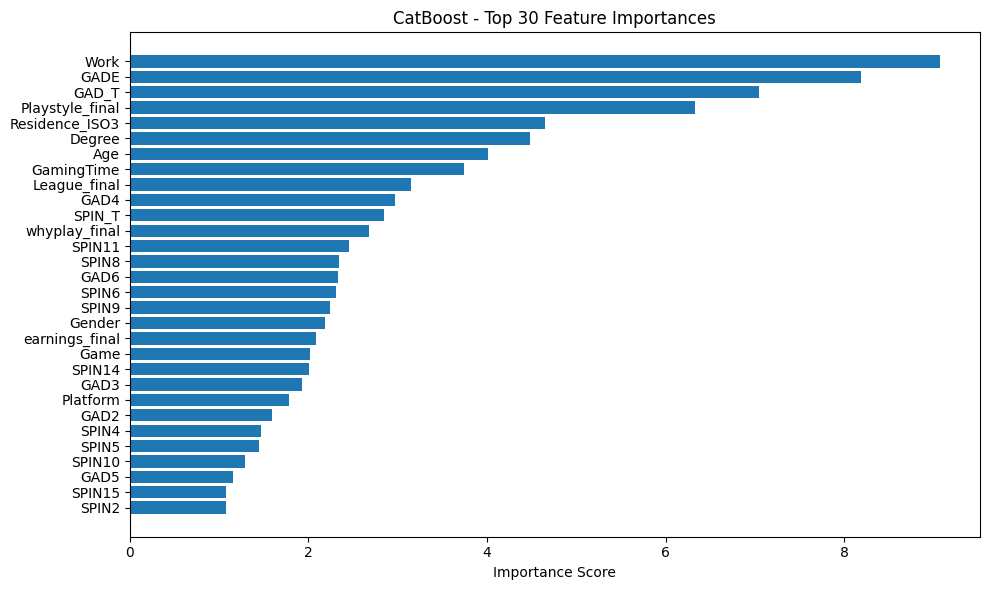

In [ ]:
# Get feature importances
catboost_importances = catboost_model_rule_tuned.get_feature_importance()
catboost_feature_names = X_train_raw.columns

# Create a DataFrame for plotting
import pandas as pd
import matplotlib.pyplot as plt

catboost_feat_imp_df = pd.DataFrame({
    'Feature': catboost_feature_names,
    'Importance': catboost_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15
plt.figure(figsize=(10, 6))
plt.barh(catboost_feat_imp_df['Feature'][:30][::-1], catboost_feat_imp_df['Importance'][:30][::-1])
plt.title("CatBoost - Top 30 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("Catboost_top30features.pdf", format='pdf', bbox_inches='tight')
plt.show()


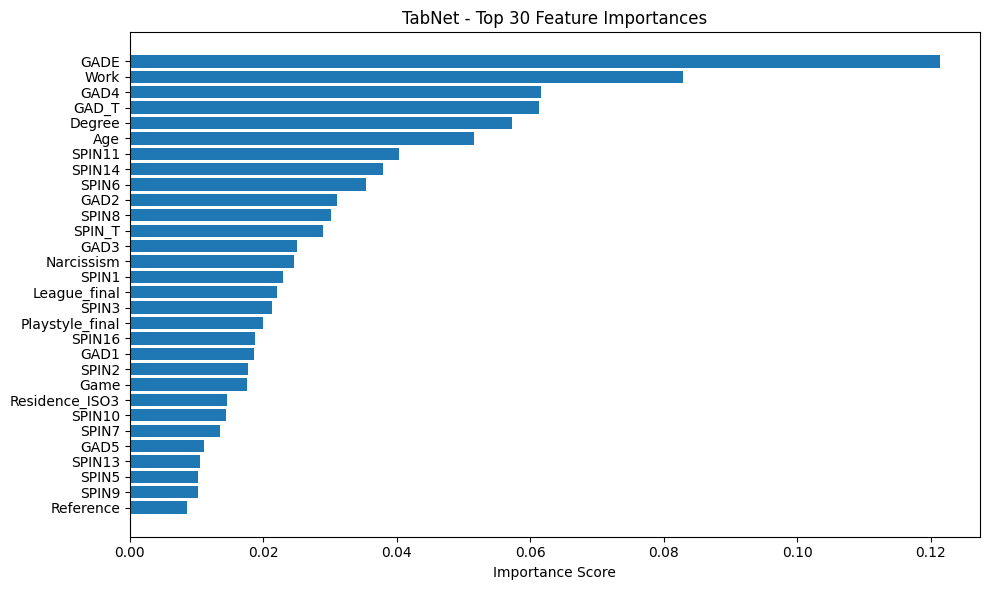

In [ ]:
tabnet_feature_importances = tabnet_model.feature_importances_

tabnet_feature_names = X_train_tabnet.columns

# Create DataFrame
tabnet_feat_imp_df = pd.DataFrame({
    'Feature': tabnet_feature_names,
    'Importance': tabnet_feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15
plt.figure(figsize=(10, 6))
plt.barh(tabnet_feat_imp_df['Feature'][:30][::-1], tabnet_feat_imp_df['Importance'][:30][::-1])
plt.title("TabNet - Top 30 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("Tabnet_top30features.pdf", format='pdf', bbox_inches='tight')
plt.show()



# 7. Error Analysis — CatBoost

Confusion matrix and per-class metrics. CatBoost accurately classifies Low and High risk 
but struggles with the Moderate risk group (F1: 0.34), reflecting overlapping 
feature distributions in this intermediate category.


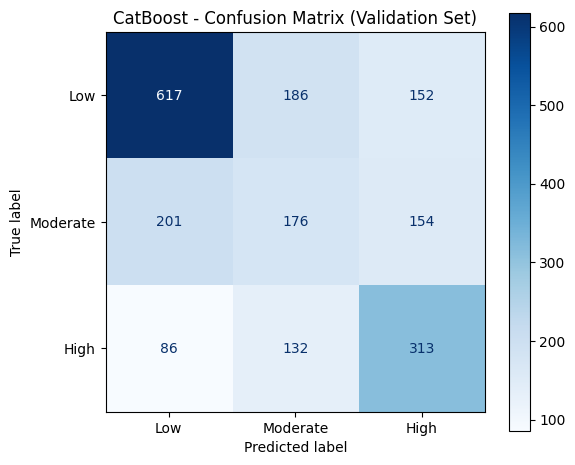

CatBoost - Classification Report (Validation Set)
              precision    recall  f1-score   support

         Low       0.68      0.65      0.66       955
    Moderate       0.36      0.33      0.34       531
        High       0.51      0.59      0.54       531

    accuracy                           0.55      2017
   macro avg       0.51      0.52      0.52      2017
weighted avg       0.55      0.55      0.55      2017



In [ ]:

# Confusion Matrix
cm = confusion_matrix(y_val_raw, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Moderate", "High"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title("CatBoost - Confusion Matrix (Validation Set)")
plt.tight_layout()

# Save for Overleaf (PDF vector format)
plt.savefig("CatBoost_ConfusionMatrix_Validation.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("CatBoost - Classification Report (Validation Set)")
print(classification_report(y_val_raw, y_val_pred, target_names=["Low", "Moderate", "High"]))

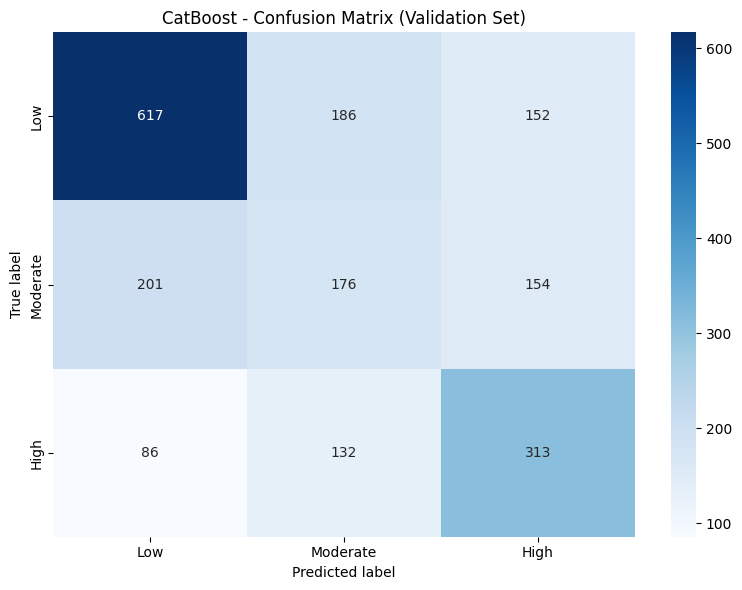

CatBoost - Classification Report (Validation Set)
              precision    recall  f1-score   support

         Low       0.68      0.65      0.66       955
    Moderate       0.36      0.33      0.34       531
        High       0.51      0.59      0.54       531

    accuracy                           0.55      2017
   macro avg       0.51      0.52      0.52      2017
weighted avg       0.55      0.55      0.55      2017



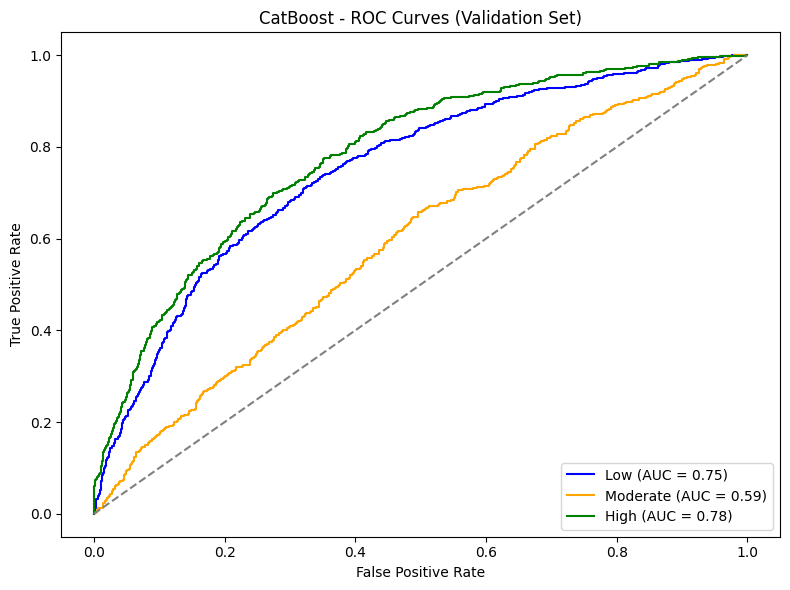

In [ ]:

# Confusion Matrix
conf_matrix = confusion_matrix(y_val_raw, y_val_pred)
labels = ['Low', 'Moderate', 'High']

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=labels, yticklabels=labels)
plt.title("CatBoost - Confusion Matrix (Validation Set)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("CatBoost_ConfusionMatrix_Validation.pdf", format='pdf')
plt.show()

# Classification Report (text block for reference — you’ll likely print this separately in your thesis)
report = classification_report(y_val_raw, y_val_pred, target_names=labels, digits=2)
print("CatBoost - Classification Report (Validation Set)")
print(report)

# ROC Curve (OvR)
y_val_bin = label_binarize(y_val_raw, classes=[0, 1, 2])
fpr, tpr, roc_auc = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_val_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']
for i in range(3):
    plt.plot(fpr[i], tpr[i], color=colors[i], label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('CatBoost - ROC Curves (Validation Set)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("CatBoost_ROC_Validation.pdf", format='pdf')
plt.show()



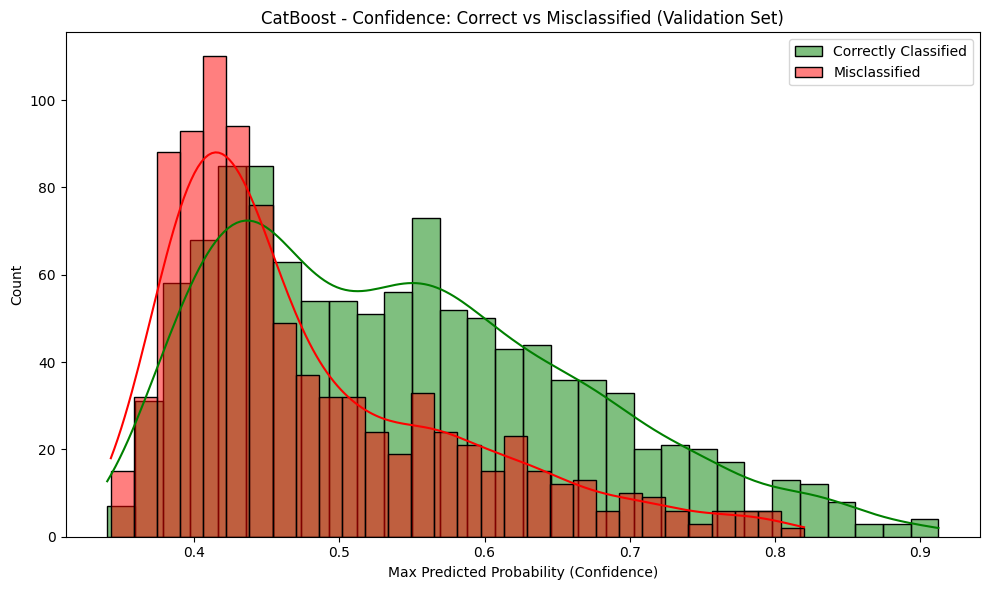

In [ ]:
# Ensure correct 1D shape
y_val_raw = np.ravel(y_val_raw)
y_val_pred = np.ravel(y_val_pred)

# Recompute masks
correct_mask = y_val_pred == y_val_raw
incorrect_mask = ~correct_mask

# Confidence histogram: Correct vs Incorrect
confidence_scores = np.max(y_val_proba, axis=1)
correct_mask = y_val_pred == y_val_raw
incorrect_mask = ~correct_mask

plt.figure(figsize=(10, 6))
sns.histplot(confidence_scores[correct_mask], bins=30, color='green', label='Correctly Classified', kde=True)
sns.histplot(confidence_scores[incorrect_mask], bins=30, color='red', label='Misclassified', kde=True)
plt.xlabel("Max Predicted Probability (Confidence)")
plt.ylabel("Count")
plt.title("CatBoost - Confidence: Correct vs Misclassified (Validation Set)")
plt.legend()
plt.tight_layout()
plt.savefig("CatBoost_Confidence_Distribution_Validation.pdf", format='pdf')
plt.show()

# 8. SHAP Interpretability Analysis

SHAP applied to CatBoost to identify the most influential predictors. 
Top features: **GADE** (functional impairment), **Work** (employment status), 
**GAD_T** (anxiety), **Playstyle**, and **Degree** (education level).


SHAP shape: (2017, 41, 3)
X_val_raw shape: (2017, 41)


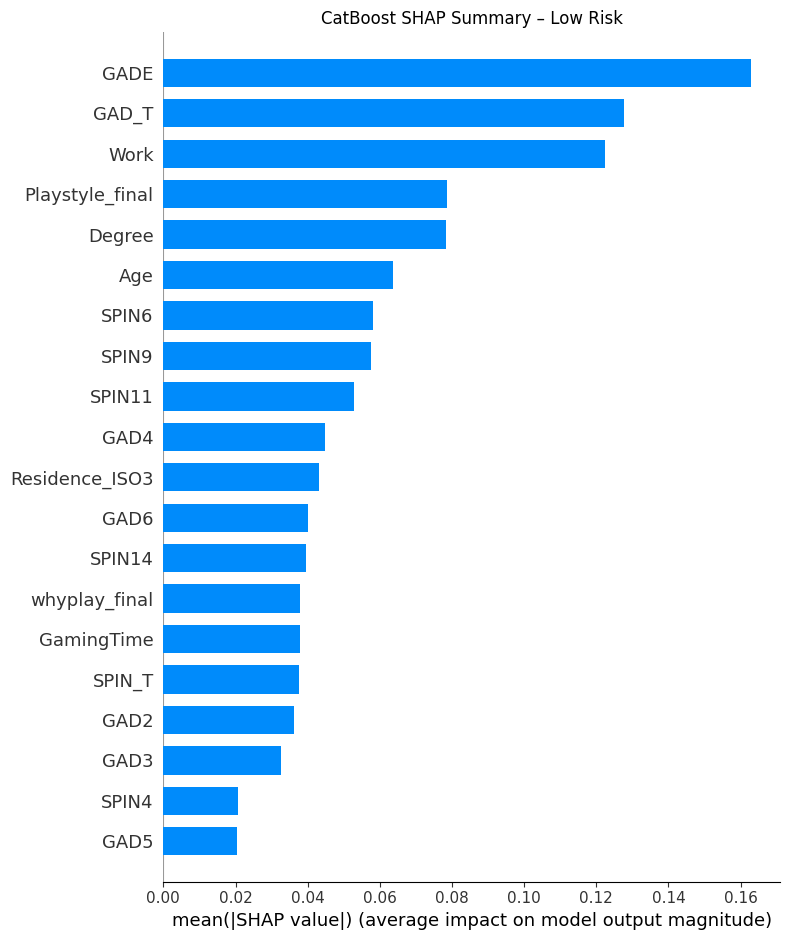

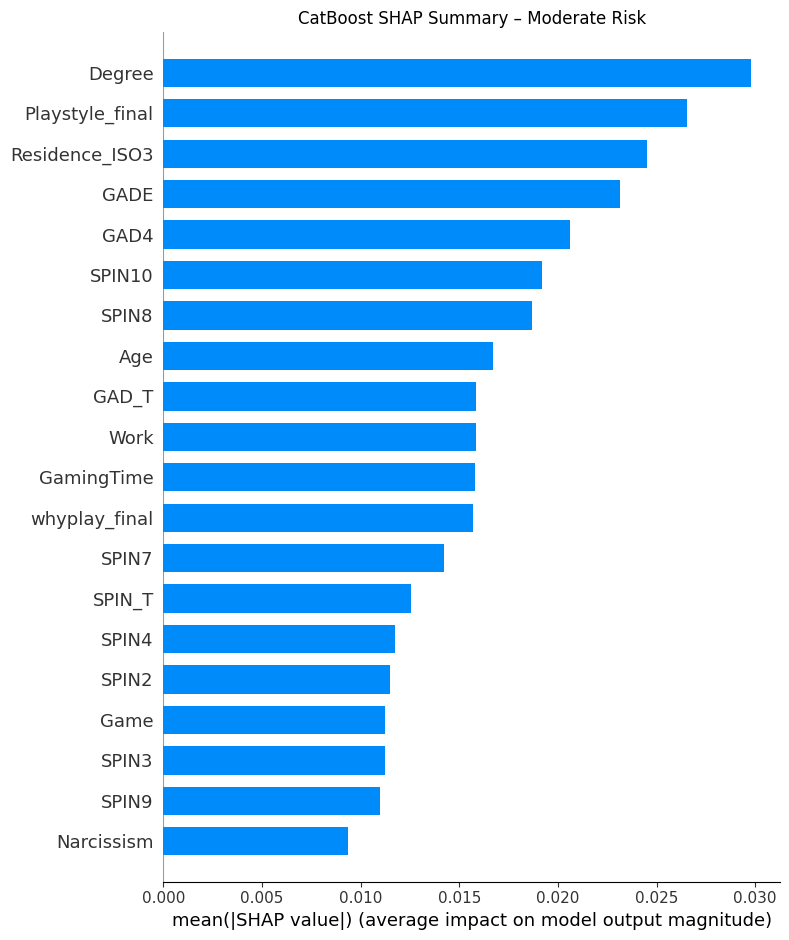

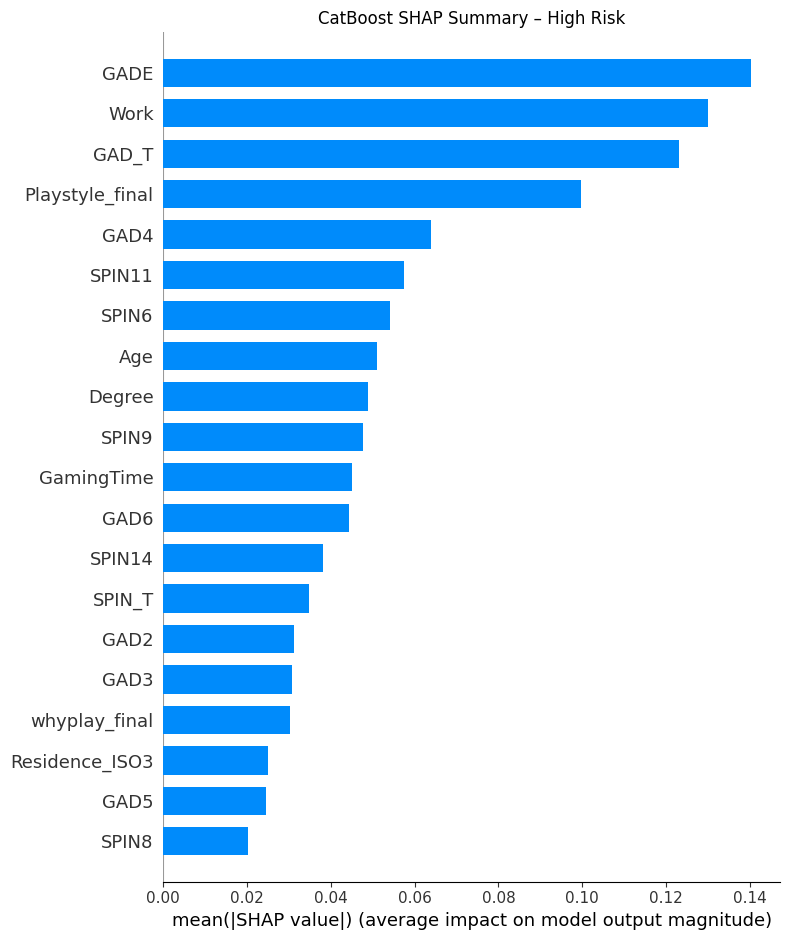

In [ ]:

# Print shapes to confirm dimensions
print(f"SHAP shape: {shap_values.shape}")
print(f"X_val_raw shape: {X_val_raw.shape}")

# Define class names
class_names = ["Low Risk", "Moderate Risk", "High Risk"]  # Adjust as needed

# Loop through each class and create a plot
for i in range(3):  # 3 classes
    plt.figure(figsize=(10, 8))

    # Extract SHAP values for class i
    # The key is to reshape the data correctly - we need shape (n_samples, n_features)
    shap_values_for_class = shap_values[:, :, i]

    # Now call summary_plot with properly shaped data
    shap.summary_plot(
        shap_values_for_class,  # Shape should be (2017, 41)
        X_val_raw,             # Shape is (2017, 41)
        plot_type="bar",
        show=False
    )

    plt.title(f"CatBoost SHAP Summary – {class_names[i]}")
    plt.tight_layout()
    plt.savefig(f"catboost_shap_{class_names[i].lower().replace(' ', '_')}.pdf", format='pdf', bbox_inches='tight')
    plt.show()

<Figure size 640x480 with 0 Axes>

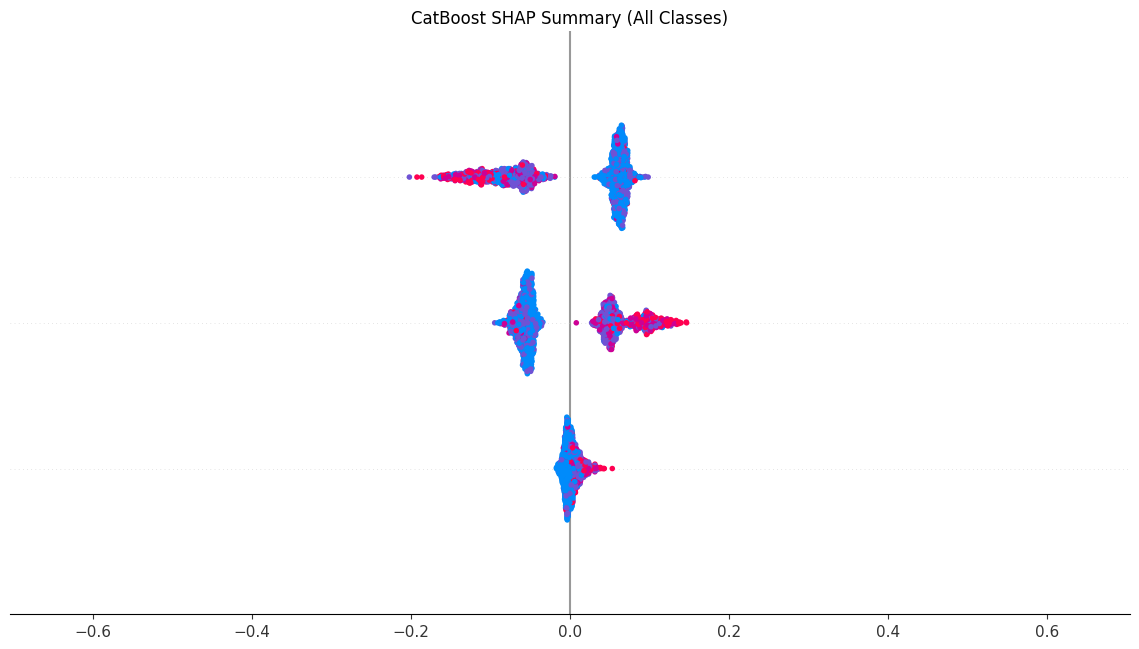

In [ ]:
shap.summary_plot(shap_values, X_val_raw, show=False)
plt.title("CatBoost SHAP Summary (All Classes)")
plt.tight_layout()
plt.savefig("catboost_shap_summary_allclasses.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
csv_file = 'X_val_rfecv_xgb_rule-2.csv'

X_val_rfecv_xgb = pd.read_csv(csv_file)

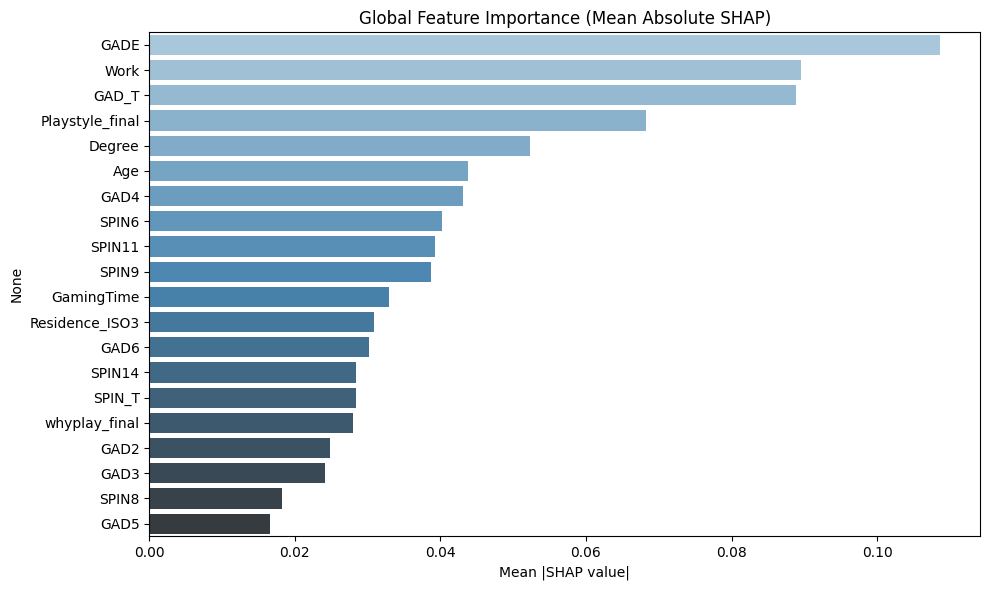

In [ ]:
# 1. Comparison Table: Top 5 SHAP Features Per Class
def top_features_per_class(shap_values, feature_names, top_n=5):
    df_list = []
    for i, class_name in enumerate(["Low Risk", "Moderate Risk", "High Risk"]):
        mean_abs_shap = np.abs(shap_values[:, :, i]).mean(axis=0)
        top_features = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False).head(top_n)
        df_list.append(top_features.rename(f"{class_name}"))
    return pd.concat(df_list, axis=1)

# 2. Global Feature Impact Ranking (mean SHAP across all classes)
def global_feature_impact(shap_values, feature_names, top_n=20):
    mean_abs = np.abs(shap_values).mean(axis=(0, 2))
    df = pd.Series(mean_abs, index=feature_names).sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=df.values, y=df.index, palette="Blues_d")
    plt.title("Global Feature Importance (Mean Absolute SHAP)")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.savefig("global_feature_importance.pdf")
    plt.show()
    return df



# Generate global impact plot
global_impact_df = global_feature_impact(shap_values, feature_names)

# Load previously extracted top features from context
catboost_top30 = global_impact_df.index.tolist()
tabnet_top30 = tabnet_feat_imp_df.sort_values("Importance", ascending=False).head(30)["Feature"].tolist()
rfecv_feats = X_val_rfecv_xgb.index.tolist()


# 9. Final Evaluation on Test Set

Unbiased final evaluation on the held-out test set. 
**CatBoost** achieved F1 Macro: **0.4882**, AUC: **0.6928**.


CatBoost - Test Set Evaluation
Accuracy:  0.5201
Precision: 0.4856
Recall:    0.4925
F1 Score:  0.4882
AUC OvR:   0.6928

Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.66      0.62      0.64       956
    Moderate       0.30      0.29      0.29       531
        High       0.50      0.57      0.53       530

    accuracy                           0.52      2017
   macro avg       0.49      0.49      0.49      2017
weighted avg       0.52      0.52      0.52      2017



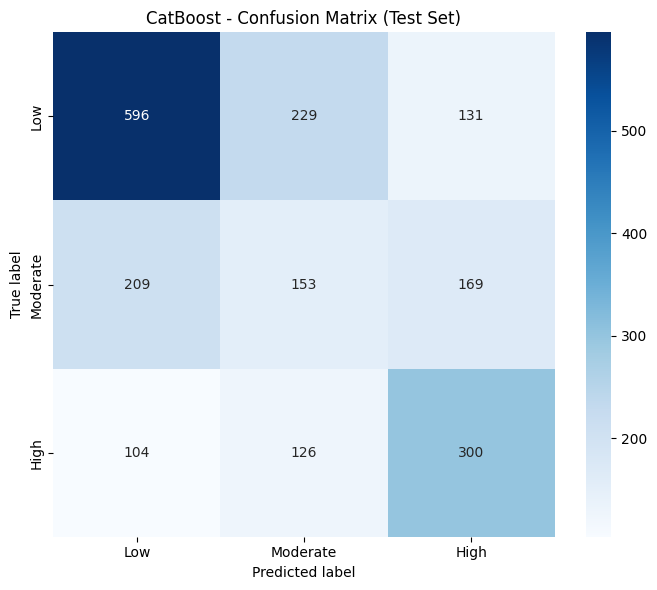

In [ ]:
# 1. Create CatBoost Pool for test set
test_pool = Pool(data=X_test_raw, cat_features=cat_features)

# 2. Predict
y_test_pred = catboost_model_rule_tuned.predict(test_pool)
y_test_proba = catboost_model_rule_tuned.predict_proba(test_pool)

# 3. Binarize labels for AUC
y_test_bin = label_binarize(y_test_raw, classes=[0, 1, 2])

# 4. Evaluation metrics
accuracy = accuracy_score(y_test_raw, y_test_pred)
precision = precision_score(y_test_raw, y_test_pred, average='macro')
recall = recall_score(y_test_raw, y_test_pred, average='macro')
f1 = f1_score(y_test_raw, y_test_pred, average='macro')
auc = roc_auc_score(y_test_bin, y_test_proba, average='macro', multi_class='ovr')

# 5. Print scores
print("CatBoost - Test Set Evaluation")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC OvR:   {auc:.4f}")

# 6. Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test_raw, y_test_pred, target_names=["Low", "Moderate", "High"]))

# 7. Confusion matrix
conf_matrix = confusion_matrix(y_test_raw, y_test_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Low", "Moderate", "High"], yticklabels=["Low", "Moderate", "High"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("CatBoost - Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("catboost_confusion_matrix_test.pdf", format="pdf")
plt.show()
